# ENGR 1451/2451 — Weekly Assignment 6
**10 points**

Practice fitting and interpreting a simple linear regression, making predictions, examining residuals and diagnostic plots, and writing a reusable function to compare model fits.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

All data are embedded below; no CSV file is needed.

Select observations by conditions, not row positions. Calculate counts, ranges, and cutoffs from the data. Label axes with units. Keep full precision in calculations and round only displayed results. Keep written comments brief and tied to your results.

Fit every regression with an **intercept**. All fit measures in this assignment describe the same observations used to fit the model. The imports below match the packages used in week 6.

In [244]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
from IPython.display import display

pd.set_option("display.precision", 6)

## LE6-1. Fit and use a regression line (3 pts)

Each row describes one laptop. `battery_Wh` is battery capacity in watt-hours and `runtime_h` is battery runtime in hours. These are synthetic observational records.

### A. Prepare the data and fit the line (1 pt)

Create `complete` by keeping the ID and both regression variables and dropping rows missing either variable. Report the retained and excluded counts.

Fit runtime from capacity with **`np.polyfit(..., deg=1)`**. Store `slope` and `intercept` and display them. Plot the observations and fitted line across the observed capacity range, with labeled axes and a legend.

Write the fitted equation and interpret the slope, including units and appropriate association wording.

**Answer:** 
$\hat{y} = 0.0999x + 1.535$. The slope is 0.0999, which means that among these laptops, laptops with 1 watt-hour more in battery on average had a 0.0999 hour longer runtime.

14 laptops retained, 2 excluded

Slope = 0.09989465115165443 
Intercept = 1.5354115787961509


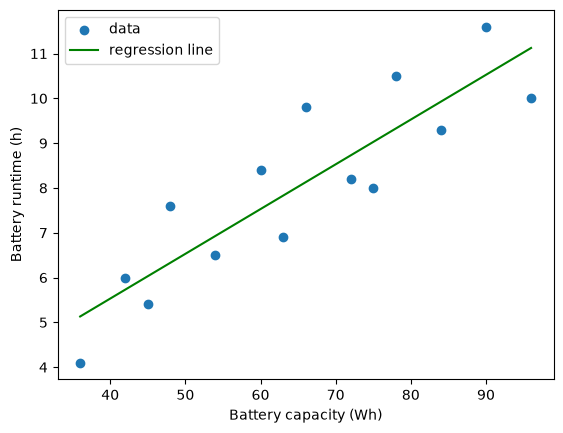

In [245]:
battery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,
              72, 75, 78, 84, 90, 96, np.nan, 80]
laptops = pd.DataFrame({
    "laptop_id": [f"L{number:02d}" for number in range(1, len(battery_Wh) + 1)],
    "battery_Wh": battery_Wh,
    "runtime_h": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,
                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],
})
xcol = "battery_Wh"
ycol = "runtime_h"
laptop_labels = {
    "battery_Wh": "Battery capacity (Wh)",
    "runtime_h": "Battery runtime (h)",
}

# Your complete-case selection and retained/excluded counts here.
complete = laptops.dropna()
retained_count = len(complete)
excluded_count = len(laptops) - retained_count
print(retained_count, "laptops retained,",excluded_count, "excluded")

# Fit with np.polyfit(), storing slope and intercept.
slope, intercept = np.polyfit(complete[xcol], complete[ycol],deg=1)
print("\nSlope =",slope,"\nIntercept =",intercept)

# Plot the observations and fitted line over the observed x range.
#prepping regression line
minimum_battery = complete[xcol].min()
maximum_battery = complete[xcol].max()
x_line_1A = np.array([minimum_battery, maximum_battery])
y_line_1A = np.polyval([slope,intercept],x_line_1A)

fig, ax = plt.subplots()
ax.scatter(complete[xcol], complete[ycol], label = "data")
ax.set_xlabel(laptop_labels[xcol])
ax.set_ylabel(laptop_labels[ycol])
ax.plot(x_line_1A, y_line_1A, c="green", label="regression line")
ax.legend()

### B. Predict and check the range (1 pt)

Add `predicted_runtime_h` and `inside_observed_range` to `prediction_data`. Use the unrounded coefficients and the observed minimum and maximum capacity; include both endpoints. Display the table.

Identify interpolation and extrapolation. Explain briefly why the intercept has limited practical meaning here and why the association does not establish the effect of replacing a laptop's battery.

**Answer:** Interpolation is prediction within a dataset (ex. 72 Wh) whereas extrapolation is prediction outside of a dataset (ex. 120 Wh). The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. The intercept is also extrapolated, since the lowest battery capacity in the dataset is 36 Wh. This association does not establish the effect of replacing a laptop's battery since it is an observational study and experiments are required to determine cause-and-effect relationships (this is because there may be a cofounding variable such as laptop size or hardware specifications that is tied to battery capacity and runtime).

In [246]:
prediction_data = pd.DataFrame({"battery_Wh": [72.0, 120.0]})

# Your predicted_runtime_h and inside_observed_range columns here.
predicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name="predicted_runtime_h")
observed_range_mask = (prediction_data[xcol] >= minimum_battery) & (prediction_data[xcol] <= maximum_battery)
inside_observed = pd.Series(observed_range_mask, name = "inside_observed_range")
prediction_data = pd.concat([prediction_data,predicted_runtime,inside_observed],axis=1)

# Display the prediction table.
prediction_data

,battery_Wh,predicted_runtime_h,inside_observed_range
0,72.0,8.727826,True
1,120.0,13.522770,False


### C. Fit with statsmodels (1 pt)

Fit **`smf.ols("runtime_h ~ battery_Wh", data=complete).fit()`** and name the model `laptop_fit`. The formula is `response ~ predictor` and includes an intercept.

Display a coefficient table comparing the NumPy values with `laptop_fit.params["Intercept"]` and `laptop_fit.params["battery_Wh"]`. Do the methods agree to the displayed precision?

**Answer:** Yes, the methods agree to the displayed precision, as the numbers dislayed in the table below match exactly.

In [247]:
# Fit laptop_fit with statsmodels.
# Compare the NumPy and statsmodels coefficients in one labeled table.
laptop_fit = smf.ols("runtime_h ~ battery_Wh",data = complete).fit()

coefficient_table = pd.DataFrame({
    "NumPy": [slope,intercept],
    "statsmodels": [laptop_fit.params["battery_Wh"],laptop_fit.params["Intercept"]],
    }, index = ["slope","intercept"])

coefficient_table

,NumPy,statsmodels
slope,0.099895,0.099895
intercept,1.535412,1.535412


## LE6-2. Residuals and fit quality (3 pts)

Use the same `complete` observations throughout this exercise.

### A. Find the largest miss (1 pt)

Create `laptop_results` by adding `fitted` and `residual` columns to a copy of `complete`, using `laptop_fit.fittedvalues` and `laptop_fit.resid`. Display the table.

Select `largest_residual_rows` using `.loc[]` and a condition on the maximum **absolute residual**. Calculate the maximum from the data and keep all ties.

Report the selected ID, observed and fitted runtimes, and signed residual. Use $e_i=y_i-\widehat y_i$ to explain whether the model overpredicts or underpredicts, with units.

**Answer:** Laptop ID L08 had the largest absolute residual, 1.6715 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours. Given this residual is positive (and residual = observed - predicted), the model underpredicts runtime by 1.6715 hours.

In [248]:
# Create and display laptop_results.
fitted = pd.Series(laptop_fit.fittedvalues, name="fitted")
residual = pd.Series(laptop_fit.resid, name = "residual")
laptop_results = pd.concat([complete,fitted,residual],axis=1)

# Select and display largest_residual_rows using a Boolean condition.
max_residual = abs(residual).max()
max_residual_mask = abs(laptop_results["residual"]) == max_residual
largest_residual_rows = laptop_results.loc[max_residual_mask]

laptop_results #display 1

,laptop_id,battery_Wh,runtime_h,fitted,residual
0,L01,36.0,4.1,5.131619,-1.031619
1,L02,42.0,6.0,5.730987,0.269013
2,L03,45.0,5.4,6.030671,-0.630671
3,L04,48.0,7.6,6.330355,1.269645
4,L05,54.0,6.5,6.929723,-0.429723
5,L06,60.0,8.4,7.529091,0.870909
6,L07,63.0,6.9,7.828775,-0.928775
7,L08,66.0,9.8,8.128459,1.671541
8,L09,72.0,8.2,8.727826,-0.527826
9,L10,75.0,8.0,9.027510,-1.027510


In [249]:
largest_residual_rows #display 2

,laptop_id,battery_Wh,runtime_h,fitted,residual
7,L08,66.0,9.8,8.128459,1.671541


### B. Calculate the residual size (1 pt)

Using the actual row count $n$, calculate

$$
\mathrm{SSE}=\sum_i e_i^2,\qquad
\mathrm{MSE}=\frac{\mathrm{SSE}}{n},\qquad
\mathrm{RMSE}=\sqrt{\mathrm{MSE}}.
$$

Display MSE in h$^2$ and RMSE in h, and interpret RMSE in one sentence. Keep `n`, `sse`, and `rmse` for part C.

**Use denominator $n$.** `laptop_fit.mse_resid` uses $n-2$; its square root is the residual standard error, a different quantity.

**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes typically differed by 0.9735 hours from the line of best fit with battery capacity in watt-hours.

In [250]:
# Calculate n, sse, mse, and rmse from laptop_results.
# Display MSE and RMSE with units.
sse = sum(laptop_results["residual"]**2)
n = len(laptop_results)
mse = sse/n
rmse = mse ** 0.5

print("Mean square error:",round(mse,4),"hours^2\nRoot mean square error:",round(rmse,4),"hours")

Mean square error: 0.9478 hours^2
Root mean square error: 0.9735 hours


### C. Compare the line with the mean-only baseline (1 pt)

Calculate

$$
\mathrm{SST}=\sum_i(y_i-\bar y)^2,\qquad
\mathrm{RMSE}_{\text{mean-only}}=\sqrt{\frac{\mathrm{SST}}{n}},\qquad
R^2=1-\frac{\mathrm{SSE}}{\mathrm{SST}}.
$$

Calculate Pearson's $r$ for the same pairs. Display the two RMSE values, your $R^2$, `laptop_fit.rsquared`, and $r^2$ together.

Interpret $R^2$ and the improvement over predicting the same mean runtime for every laptop. These measures describe the fitting data; do they establish performance on new laptops?

**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime does. These measures do not establish performance on new laptops since they were computed based on this specific dataset, which might not be representative of a dataset of new laptops.

In [251]:
# Calculate sst, mean-only RMSE, R-squared, and Pearson r.
# Display the two RMSE values and compare the three R-squared values.
sst = sum((laptop_results["runtime_h"]-laptop_results["runtime_h"].mean())**2)
rmse_mean_only = (sst/n) ** 0.5
squared_R = 1-(sse/sst)
r_laptop = complete[xcol].corr(complete[ycol])

print(
    "RMSE =",round(rmse,3), "hours",
    "\nRMSE mean-only =",round(rmse_mean_only,3), "hours",
    "\nR^2 =",squared_R,
    "\nlaptop_fit.rsquared =",laptop_fit.rsquared,
    "\nr^2 =",r_laptop**2,
)


RMSE = 0.974 hours 
RMSE mean-only = 2.034 hours 
R^2 = 0.7709305307516051 
laptop_fit.rsquared = 0.7709305307516052 
r^2 = 0.7709305307516049


## LE6-3. Check the center, spread, and shape (2 pts)

**Run the plotting helper unchanged.** It displays the fitted line, residuals versus the predictor, a residual histogram, and a normal probability (Q-Q) plot. Approximate alignment with the Q-Q reference line is a rough check of Gaussian shape.

Gaussian shape concerns the model errors; the raw predictor and response need not be normally distributed, and normality is not required to calculate a least-squares line.

In [252]:
# Provided plotting code: run this cell unchanged.
def plot_regression_diagnostics(data, fit, xcol, ycol, xlabel, ylabel,
                                residual_label, title):
    """Display four diagnostics for the same observations used to fit the model."""
    x_grid = np.linspace(data[xcol].min(), data[xcol].max(), 100)
    new_data = pd.DataFrame({xcol: x_grid})
    residuals = fit.resid
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

    ax = axes[0, 0]
    ax.scatter(data[xcol], data[ycol], alpha=0.75)
    ax.plot(x_grid, fit.predict(new_data), color="darkorange",
            linewidth=2, label="Least-squares line")
    ax.set(xlabel=xlabel, ylabel=ylabel, title="Observations and fitted line")
    ax.legend()

    ax = axes[0, 1]
    ax.scatter(data[xcol], residuals, alpha=0.75)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set(xlabel=xlabel, ylabel=residual_label, title="Residuals versus predictor")

    ax = axes[1, 0]
    ax.hist(residuals, bins="auto", edgecolor="black")
    ax.set(xlabel=residual_label, ylabel="Count", title="Residual histogram")

    (theoretical, ordered), (qq_slope, qq_intercept, _) = stats.probplot(
        residuals, dist="norm", fit=True
    )
    ax = axes[1, 1]
    ax.scatter(theoretical, ordered, alpha=0.75)
    reference_x = np.array([theoretical.min(), theoretical.max()])
    ax.plot(reference_x, qq_intercept + qq_slope * reference_x,
            color="darkorange", linewidth=2)
    ax.set(xlabel="Theoretical normal quantile", ylabel=residual_label,
           title="Normal probability (Q-Q) plot")

    fig.suptitle(title, fontsize=14)
    plt.show()
    return axes



### A. Inspect the laptop model (1 pt)

Call `plot_regression_diagnostics()` for `complete` and `laptop_fit`, using `laptop_labels`, `"Residual (h)"`, and title `"Laptop runtime model"`.

Complete the table with brief observations. Use cautious language for this small dataset: the plots provide evidence but do not prove the assumptions.

| Check | Evidence from the laptop plots |
|---|---|
| Center: clear residual curvature? | No, the data shows no sign of curvature on the scatter plot nor the residual plot |
| Spread: a clear fan or funnel? | No clear sign of a fan or funnel; residuals appear randomly scattered |
| Shape: roughly Gaussian residuals? | No, the histogram of the residuals is bimodal (though this can be due to the dataset being small, leaving it more dependent on bin choice) and the normal probability plot has a nonlinear s shape |

**Answer:** The plots show no warning signs for center or spread; however, the shape shows warning signs, as the histogram of residuals is bimodal and the normal probability plot is nonlinear.

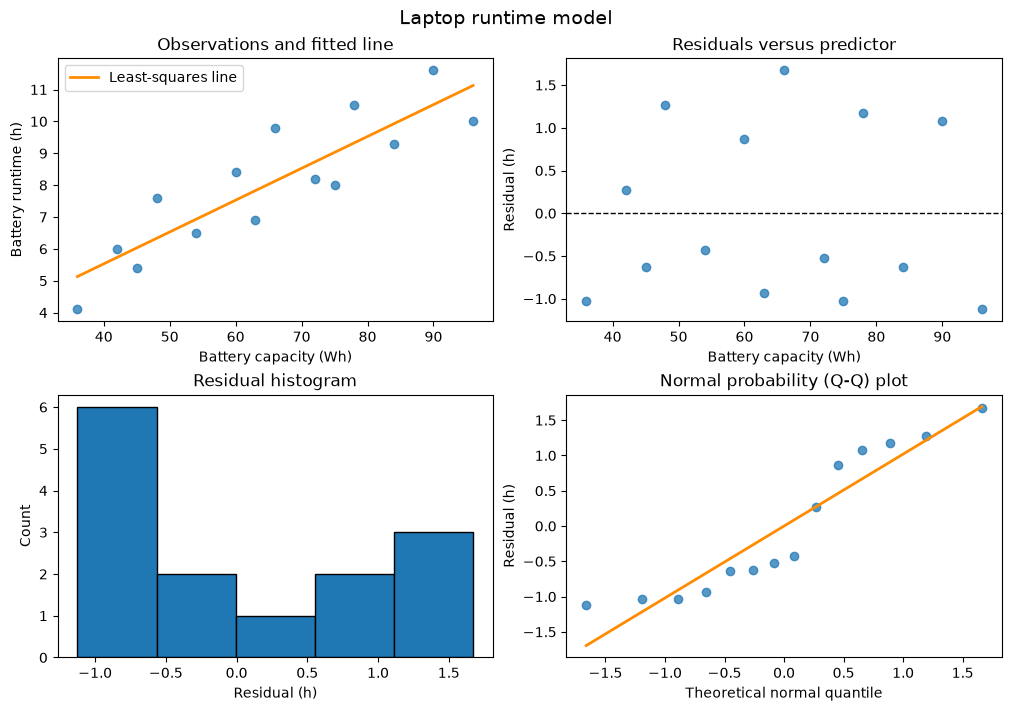

In [253]:
# Your call to plot_regression_diagnostics() for the laptop model here.
axes = plot_regression_diagnostics(complete, laptop_fit, xcol, ycol, laptop_labels[xcol], laptop_labels[ycol], "Residual (h)", "Laptop runtime model")

### B. Compare two diagnostic problems (1 pt)

Run the provided code. `runs` contains synthetic process yield measurements (% of starting material recovered); `sensor` contains simulated signal measurements (mV) at applied loads (N).

The code fits each model and displays its residual plot. Complete the table, distinguishing a problem with the average relationship from a problem with the spread. Why would a residual histogram alone be insufficient to check these features?

| Dataset | Main concern: center or spread? | Plot evidence |
|---|---|---|
| Process yield | Center | Curved Residual Plot, downturned parabola of residuals as opposed to random scatter |
| Sensor calibration | Spread | Heteroscedastic Residual Plot, residuals fan out as applied load increases |

**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved and fanning residual patterns. This is because the histogram only displays the residuals and their counts, not the temperature/load values associated with them.

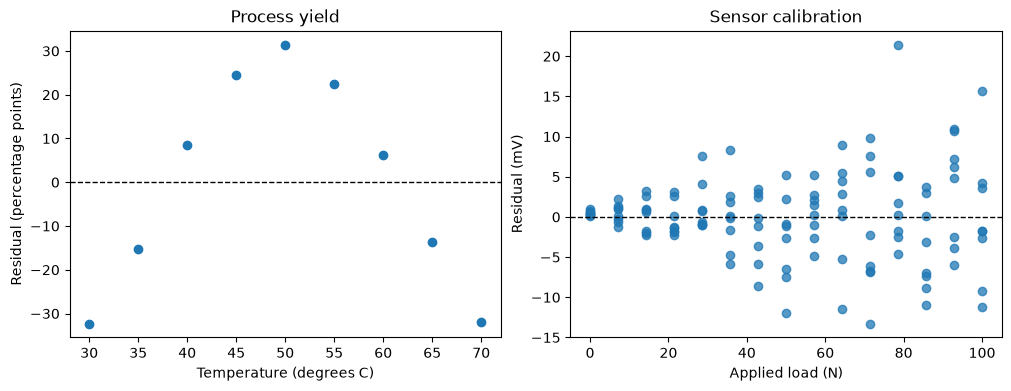

In [254]:
# Provided data, fits, and plots: run this cell unchanged.
runs = pd.DataFrame({
    "temperature_C": [30, 35, 40, 45, 50, 55, 60, 65, 70],
    "yield_pct": [31, 48, 72, 88, 95, 86, 70, 50, 32],
})
rng = np.random.default_rng(1451)
load_N = np.repeat(np.linspace(0, 100, 15), 8)
sensor = pd.DataFrame({
    "load_N": load_N,
    "signal_mV": 10 + 1.2 * load_N
                 + (0.5 + 0.08 * load_N) * rng.normal(size=load_N.size),
})

yield_fit = smf.ols("yield_pct ~ temperature_C", data=runs).fit()
sensor_fit = smf.ols("signal_mV ~ load_N", data=sensor).fit()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axes[0].scatter(runs["temperature_C"], yield_fit.resid)
axes[0].set(xlabel="Temperature (degrees C)",
            ylabel="Residual (percentage points)", title="Process yield")
axes[1].scatter(sensor["load_N"], sensor_fit.resid, alpha=0.75)
axes[1].set(xlabel="Applied load (N)", ylabel="Residual (mV)",
            title="Sensor calibration")
for ax in axes:
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
plt.show()

## LE6-4. Write a function and compare sensitivity (2 pts)

Large residuals measure vertical misses; **leverage** concerns how far $x$ is from its center. Compare fits to assess **influence on the slope**.

### A. Write and call your function (1 pt)

Write **`fit_and_summarize(data)`** to fit `runtime_h ~ battery_Wh` with statsmodels and return a `pd.Series` containing `"n"`, `"intercept_h"`, `"slope_h_per_Wh"`, and `"RMSE_h"`. Use denominator $n$ for RMSE.

Use the `data` argument and locally fitted model for every calculation. Return full-precision numbers; do not use `complete`, `laptop_fit`, or earlier coefficients inside the function.

**First call:** Analyze `complete`, store the result as `all_summary`, and display it.

In [255]:
def fit_and_summarize(data):
    """Return n, intercept, slope, and RMSE for the supplied observations."""
    # Write your function body here.
    fit = smf.ols("runtime_h ~ battery_Wh",data = data).fit()
    n = len(data)
    intercept_h, slope_h_per_Wh = fit.params
    RMSE_h = ((sum(fit.resid**2))/n)**0.5


    return pd.Series({"n": n,
        "intercept_h": intercept_h,
        "slope_h_per_Wh": slope_h_per_Wh,
        "RMSE_h": RMSE_h})


# First call: analyze complete and display all_summary.
all_summary = fit_and_summarize(complete)

all_summary

n                 14.000000
intercept_h        1.535412
slope_h_per_Wh     0.099895
RMSE_h             0.973525
dtype: float64

### B. Compare two omissions (1 pt)

Calculate absolute capacity distances from the mean in `complete`. Select `farthest_capacity_rows` with a condition on the maximum distance, keeping all ties. Display their IDs and capacities.

Create two separate datasets by filtering `complete` on `laptop_id`:

- `without_largest_residual`: exclude IDs in `largest_residual_rows` from LE6-2A.
- `without_farthest_capacity`: exclude IDs in `farthest_capacity_rows`.

**Second and third calls:** Apply your function to the two reduced datasets. Combine their returned Series with `all_summary` into a table with one row per dataset. Add `slope_change` relative to the original slope; display slopes and changes to at least five decimal places. Keep fitting and summary calculations inside the function.

Which omission changes the slope more? Compare this with the largest-residual observation. Explain why an improved fit measure alone would not justify deleting a valid observation.

**Answer:** The omission of the furthest capacity changed the slope more (by about 0.01 as opposed to 0.0004). The largest residual laptop was L08 (with the greatest difference between the regression line and observed value), whereas the farthest capacity laptop was L14 (with the furthest value from the mean battery capacity). An improved measure of fit does not justify deleting a valid observation because it would mean discarding part of the dataset. Unless that value was caused by a measurement or calibration error, it is a valid part of the fit.

In [256]:
# Select and display farthest_capacity_rows.
mean_capacity = complete["battery_Wh"].mean()
abs_distances = abs(complete["battery_Wh"]-mean_capacity)
abs_max_capacity = abs_distances.max()
farthest_capacity_rows = complete[abs_distances==abs_max_capacity]

display(farthest_capacity_rows[["laptop_id","battery_Wh"]])
display(largest_residual_rows)

# Filter complete to create both reduced datasets.
without_farthest_capacity = complete[~complete["laptop_id"].isin(farthest_capacity_rows["laptop_id"])]
without_largest_residual = complete[~complete["laptop_id"].isin(largest_residual_rows["laptop_id"])]

# Call fit_and_summarize() for each reduced dataset.
summary_without_largest_residual = fit_and_summarize(without_largest_residual)
summary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)

# Combine the three returned Series and add slope_change.
final_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)
final_display_table.columns = ["All Data","Without Largest Residual","Without Farthest Capacity"] #renaming columns
final_display_table = final_display_table.transpose() #switching rows and columns
slope_change = final_display_table["slope_h_per_Wh"] - slope
slope_change = slope_change.rename("slope_change")
final_display_table = pd.concat([final_display_table,slope_change],axis=1)

final_display_table

,laptop_id,battery_Wh
13,L14,96.0


,laptop_id,battery_Wh,runtime_h,fitted,residual
7,L08,66.0,9.8,8.128459,1.671541


,n,intercept_h,slope_h_per_Wh,RMSE_h,slope_change
All Data,14.0,1.535412,0.099895,0.973525,-1.387779e-17
Without Largest Residual,13.0,1.434788,0.099464,0.888331,-4.311208e-04
Without Farthest Capacity,13.0,0.936477,0.110856,0.940216,1.096119e-02


## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA6",
  "export_n": 1,
  "session_date": "2026-10-08",
  "messages": [
    {"i": 1, "who": "student", "text": "Is polyfit and polyval with numpy the same as in MATLAB?"},
    {"i": 2, "who": "tutor", "text": "Very close, with a couple of differences worth knowing. Coefficients come back highest power first in both; np.polyfit with deg=1 returns slope then intercept; np.polyval(p, x) uses the same order. Differences: NumPy returns a 1-D array you can unpack (b1, b0 = np.polyfit(x, y, deg=1)), indexing starts at 0, deg can be a keyword, extra outputs need full=True or cov=True, np.nan in the inputs raises LinAlgError, and powers use ** with element-wise * on arrays. [trimmed: generic cost-versus-hours example and closing question]"},
    {"i": 3, "who": "student", "text": "Is there a reason to use polyval over this:\n\n```python\ny_line_1A = intercept_1A + slope_1A * x_line_1A\n```", "code": true},
    {"i": 4, "who": "tutor", "text": "No strong reason here. Both compute exactly the same numbers for a straight line. np.polyval earns its keep for higher degrees and when the degree may change; writing the formula directly is more readable for lines and works with the stored names. Your version works on arrays and Series but not plain lists. [trimmed]"},
    {"i": 5, "who": "student", "text": "Understood, thank you!"},
    {"i": 6, "who": "tutor", "text": "You're welcome. Your intercept_1A + slope_1A * x_line_1A line is a clear way to write the straight-line formula. [trimmed: offer to continue and reminder about \"make my record\"]"},
    {"i": 7, "who": "student", "text": "What would be the way to write the following in LaTeX for jupyter?\n\n```markdown\nyhat = 0.0999*x + 1.535\n```"},
    {"i": 8, "who": "tutor", "text": "Jupyter markdown cells render LaTeX between dollar signs: one on each side for inline, two for display math. Use \\hat{y} for the hat, write the number next to the variable or use \\cdot, \\text{...} for words, _ for subscripts. [trimmed: generic cost-versus-hours examples, notes about running the markdown cell and keeping stored coefficients at full precision]"},
    {"i": 9, "who": "student", "text": "Would this be an accurate analysis of the regression line values?\n\n```markdown\nThe slope is 0.0999, which means that for every additional Watt hour of battery, a laptop runtime is predicted to increase by an average of 0.0999 hours.\n```"},
    {"i": 10, "who": "tutor", "text": "Your number and units are right. The part I would push on is the wording: the prompt asks for appropriate association wording, and these are observational records of different laptops, not one laptop whose battery was changed. What does the slope actually compare in these data? [trimmed: small notes on \"watt-hour\" and the article]"},
    {"i": 11, "who": "student", "text": "Is this closer?\n\n```markdown\nThe slope is 0.0999, which means that an increase of 1 Watt hour of battery is associated with an increase in laptop runtime by an average of 0.0999 hours.\n```"},
    {"i": 12, "who": "tutor", "text": "Closer, yes. \"Associated with\" and \"an average of\" move toward association wording. It still leaves open the comparison: who is being compared when the slope is computed from these sixteen records? [trimmed: reminder that the equation is also required, small tidy-ups]"},
    {"i": 13, "who": "student", "text": "Also does this code miss anything for 1A?\n\n```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope_1A, intercept_1A = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope_1A,\"\\nIntercept =\",intercept_1A)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope_1A,intercept_1A],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol])\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Your cell does most of what 1A asks. Two things to check: the prompt says to store slope and intercept, and later parts use those exact names; and ax.legend() only lists the line because the scatter has no label=. What argument could you add to ax.scatter? [trimmed: note that the Answer field still needs the equation and slope sentence]"},
    {"i": 15, "who": "student", "text": "```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope, intercept = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope,\"\\nIntercept =\",intercept)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope,intercept],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol], label = \"data\")\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 16, "who": "tutor", "text": "This version covers everything the code side of 1A asks for: complete keeps the ID, both counts are calculated, slope and intercept use the expected names, and the legend lists both. The Answer field still needs the fitted equation and your slope interpretation. [trimmed]"},
    {"i": 17, "who": "student", "text": "```markdown\n$\\hat{y} = 0.0999*x + 1.535$\nThe slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is predicted to increase by 0.0999 hours.\n```"},
    {"i": 18, "who": "tutor", "text": "Your equation matches the coefficients I get. Inside math mode the * prints as a literal asterisk, and a blank line is needed between the equation and the sentence. The sentence went backwards from your last draft: it is back to reading as one laptop being upgraded. What is the slope comparing? [trimmed]"},
    {"i": 19, "who": "student", "text": "The slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is associated with an average increase of 0.0999 hours."},
    {"i": 20, "who": "tutor", "text": "Closer: \"associated with\" and \"an average\" are back. The sentence still leaves open the comparison; the data are different laptops, so what would you say about laptops that differ by 1 Wh in capacity? [trimmed: reminder about the stray * and blank line]"},
    {"i": 21, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that a 1 watt-hour battery increase among laptops is associated with an average increase in runtime by 0.0999 hours.\n```"},
    {"i": 22, "who": "tutor", "text": "The closest yet: \"among laptops\" brings the group comparison in. \"Increase\" still suggests something being changed; whether to rephrase in terms of laptops that differ by 1 Wh is your call. [trimmed: check that the Answer cell holds both equation and interpretation]"},
    {"i": 23, "who": "student", "text": "Can you give an example of proper association wording? Also how are we able to assume association from just a best fit line? Wouldnt we need to see a correlation coefficient first?"},
    {"i": 24, "who": "tutor", "text": "Gave an example on invented data (exam score versus weekly study time, slope 2.0 points per hour) showing the wording features: compares different units, says on average, states the difference with units. On the second question: the slope is already a measure of association (slope = r x (sy/sx), same sign as r), r adds strength on a unit-free scale, a line can be fit to any cloud so the scatterplot and r or R-squared matter, and association is not causation. [trimmed]"},
    {"i": 25, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that among these laptops, laptops with 1 watt-hour more in battery on average had a 0.0999 hour longer runtime.\n```"},
    {"i": 26, "who": "tutor", "text": "This version does what the prompt's appropriate association wording asks: it compares laptops that differ by 1 Wh, says on average, and has the right number and units. Check that the Answer cell has the equation without the stray * and a blank line before the sentence. [trimmed]"},
    {"i": 27, "who": "student", "text": "Can you help me troubleshoot my code?"},
    {"i": 28, "who": "tutor", "text": "Happy to. Paste the cell you're working on, along with its output or full traceback, and tell me which part it belongs to. [trimmed]"},
    {"i": 29, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = {\"predicted_runtime\": np.polyval([slope,intercept],prediction_data[xcol])}\npd.concat(prediction_data, predicted_runtime,axis=0)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 30, "who": "tutor", "text": "The np.polyval prediction is on the right track. Problems in the pd.concat line: it takes a list as its first argument, the dictionary is not a pandas object, axis=0 stacks rows instead of adding a column, and the result is never stored. You don't need concat: adding a column is assignment (generic trips example). Also the prompt names the column predicted_runtime_h. Next is inside_observed_range: which comparison operators include an endpoint, and where will min and max come from? [trimmed]"},
    {"i": 31, "who": "student", "text": "How can I change my code to make a pandas series?"},
    {"i": 32, "who": "tutor", "text": "A pd.Series is a one-dimensional labeled column; built from a list, array, or dictionary (generic examples with name= and index=). np.polyval returns an array, which pd.Series(...) can wrap, but you do not need a Series to add a column; a Series matters when passing pandas objects to pd.concat(axis=1). [trimmed]"},
    {"i": 33, "who": "student", "text": "How can I convert a numpy array into a series?"},
    {"i": 34, "who": "tutor", "text": "Wrap the array in pd.Series(...), with optional index= and name=; default labels are 0, 1, 2; s.to_numpy() converts back; arithmetic on a Series stays a Series. [trimmed: generic temperature example]"},
    {"i": 35, "who": "student", "text": "How do I title the series so that the name will transfer over to pd.concat?"},
    {"i": 36, "who": "tutor", "text": "Use the name= argument; with pd.concat(..., axis=1) each Series name becomes its column label. Other ways: s.name = ..., s.rename(...), or keys= in concat. Watch the list brackets, axis=1 versus 0, matching row labels, and storing the result. Reminder that the prompt wants the column called predicted_runtime_h. [trimmed: generic miles/cost example]"},
    {"i": 37, "who": "student", "text": "The column is still titled battery_Wh, is there anything wrong with my code? \n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nprediction_data = pd.concat([prediction_data,prediction_data],axis=1)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 38, "who": "tutor", "text": "Yes, one thing: you wrote [prediction_data, prediction_data], combining the table with a copy of itself. Your new Series is built correctly but never passed to concat. Which two objects do you want side by side? [trimmed: note on inside_observed_range still to come and rerun behavior of overwriting prediction_data]"},
    {"i": 39, "who": "student", "text": "Without [prediction_data, prediction_data] I get an error"},
    {"i": 40, "who": "tutor", "text": "That is useful information, but I can't tell which error without seeing it. Paste the full traceback or its last line with the cell. Meanwhile, check what you put in the list in place of the duplicate and that names are spelled exactly. [trimmed]"},
    {"i": 41, "who": "student", "text": "Traceback (most recent call last)\nCell In[66], line 5\n      1 prediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n      2 \n      3 # Your predicted_runtime_h and inside_observed_range columns here.\n      4 predicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\n----> 5 prediction_data = pd.concat(prediction_data,axis=1)\n      6 \n      7 # Display the prediction table.\n      8 prediction_data\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\reshape\\concat.py:407, in concat(objs, axis, join, ignore_index, keys, levels, names, verify_integrity, sort, copy)\n    402 else:  # pragma: no cover\n    403     raise ValueError(\n    404         \"Only can inner (intersect) or outer (union) join the other axis\"\n    405     )\n--> [407](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/reshape/concat.py:407) objs, keys, ndims = _clean_keys_and_objs(objs, keys)\n    409 if sort is lib.no_default:\n    410     if axis == 0:\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\reshape\\concat.py:800, in _clean_keys_and_objs(objs, keys)\n    798     objs = [objs[k] for k in keys]\n    799 elif isinstance(objs, (ABCSeries, ABCDataFrame)) or is_scalar(objs):\n--> [800](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/reshape/concat.py:800)     raise TypeError(\n...\n    803     )\n    804 elif not isinstance(objs, abc.Sized):\n    805     objs = list(objs)\n\nTypeError: first argument must be an iterable of pandas objects, you passed an object of type \"DataFrame\"\nOutput is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings..."},
    {"i": 42, "who": "tutor", "text": "The traceback matches its last line: pd.concat(prediction_data, axis=1) passes a single DataFrame, but concat wants a list of pandas objects. When you deleted the duplicate, the brackets went with it. The list needs the table and the Series from line 4, wrapped in square brackets. [trimmed]"},
    {"i": 43, "who": "student", "text": "Thank you, I misunderstood"},
    {"i": 44, "who": "tutor", "text": "No problem, an easy one to trip on. Next is the inside_observed_range column: a True/False test of each capacity against the min and max in complete, both endpoints inside. [trimmed]"},
    {"i": 45, "who": "student", "text": "What is inside_observed_range supposed to be?"},
    {"i": 46, "who": "tutor", "text": "A column of True/False values, one per row of prediction_data, answering whether each capacity falls within the range of capacities in complete, both ends included. It flags interpolation versus extrapolation. Bounds should be calculated from complete; both endpoints included means >= and <=. Gave syntax shapes on invented data: (df[\"temp\"] >= lo) & (df[\"temp\"] <= hi) or .between(lo, hi). [trimmed]"},
    {"i": 47, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = prediction_data[xcol] < minimum_battery | prediction_data[xcol] > maximum_battery\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nCan you help me troublshoot this?\n---------------------------------------------------------------------------\nTypeError                                 Traceback (most recent call last)\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\ops\\array_ops.py:374, in na_logical_op(x, y, op)\n    365 try:\n    366     # For exposition, write:\n    367     #  yarr = isinstance(y, np.ndarray)\n   (...)    372     # Then Cases where this goes through without raising include:\n    373     #  (xint or xbool) and (yint or bool)\n--> [374](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/ops/array_ops.py:374)     result = op(x, y)\n    375 except TypeError:\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\roperator.py:59, in ror_(left, right)\n     58 def ror_(left, right):\n---> [59](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/roperator.py:59)     return operator.or_(right, left)\n\nTypeError: ufunc 'bitwise_or' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''\n\nDuring handling of the above exception, another exception occurred:\n\nValueError                                Traceback (most recent call last)\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\ops\\array_ops.py:388, in na_logical_op(x, y, op)\n    387 try:\n--> [388](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/ops/array_ops.py:388)     result = libops.scalar_binop(x, y, op)\n    389 except (\n    390     TypeError,\n...\n    399                 f\"and scalar of type [{typ}]\"\n    400             ) from err\n    402 return result.reshape(x.shape)\n\nTypeError: Cannot perform 'ror_' with a dtyped [float64] array and scalar of type [bool]", "code": true},
    {"i": 48, "who": "tutor", "text": "The error comes from the observed_range_mask line, with two problems: missing parentheses (| and & bind more tightly than < and >, so each comparison needs its own parentheses) and flipped logic (your test is True when a capacity is outside the range; the column should be True inside, with both endpoints). Also inside_observed never gets into the concat list, and minimum_battery and maximum_battery are not defined in this cell. [trimmed]"},
    {"i": 49, "who": "student", "text": "```markdown\nInterpolation is prediction within a dataset whereas extrapolation is prediction outside of a dataset. The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. This association does not establish the effect of replacing a laptop's battery since it is an observational study, and experiments are required to determine cause-and-effect relationships.\n```\n\n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = (prediction_data[xcol] > minimum_battery) & (prediction_data[xcol] < maximum_battery)\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime,inside_observed],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nIs this sufficient for 1B?", "code": true},
    {"i": 50, "who": "tutor", "text": "The table side is close. Code: > and < are strict, and the prompt says to include both endpoints; check that minimum_battery and maximum_battery are calculated from complete above this cell. Written answer: identify which of 72 Wh and 120 Wh is interpolation and extrapolation using the range from complete; compare 0 Wh with the smallest capacity in complete; the causation sentence reads as a slogan, so say what else might differ between laptops with bigger and smaller batteries. Also spelling of limmited and likley. [trimmed]"},
    {"i": 51, "who": "student", "text": "```markdown\n**Answer:** Interpolation is prediction within a dataset (ex. 72 Wh) whereas extrapolation is prediction outside of a dataset (ex. 120 Wh). The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. The intercept is also extrapolated, since the lowest battery capacity in the dataset is 36 Wh. This association does not establish the effect of replacing a laptop's battery since it is an observational study and experiments are required to determine cause-and-effect relationships.\n```"},
    {"i": 52, "who": "tutor", "text": "A real improvement: 72 Wh as interpolation, 120 Wh as extrapolation, and the intercept as an extrapolation since 0 Wh is below 36 Wh are correct. Still open: the causation sentence is the general rule rather than something about these laptops (pick one or two things that could differ between laptops); I can't tell whether you fixed the operators in the code; within a dataset is loose wording; spelling. [trimmed]"},
    {"i": 53, "who": "student", "text": "I made the changes to my code, thank you!"},
    {"i": 54, "who": "tutor", "text": "Glad you got those changes in; run Restart Kernel and Run All once before submitting. The causation sentence and spelling fixes are still open for 1B. 1C is next whenever you are ready. [trimmed]"},
    {"i": 55, "who": "student", "text": "Did I miss anything for 1C?\n\n```python\n# Fit laptop_fit with statsmodels.\n# Compare the NumPy and statsmodels coefficients in one labeled table.\nlaptop_fit = smf.ols(\"runtime_h ~ battery_Wh\",data = complete).fit()\n\ncoefficient_table = pd.DataFrame({\n    \"NumPy\": [slope,intercept],\n    \"statsmodels\": [laptop_fit.params[\"battery_Wh\"],laptop_fit.params[\"Intercept\"]],\n    }, index = [\"slope\",\"intercept\"])\n\ncoefficient_table\n```\n\n\n```markdown\n**Answer:** Yes, the methods agree to the displayed precision.\n```", "code": true},
    {"i": 56, "who": "tutor", "text": "The code side of 1C looks complete: laptop_fit named correctly, fit on complete with .fit(), rows and columns labeled, values pulled by name. The Answer has the right verdict but does not point to your own numbers: how many decimals does the table show, is agree the same as identical in every digit, and how could you look at the size of the difference? [trimmed]"},
    {"i": 57, "who": "student", "text": "Got it, thank you@"},
    {"i": 58, "who": "tutor", "text": "You're welcome. Your 1C code is solid. When you've revised the Answer sentence, 2A is next. [trimmed]"},
    {"i": 59, "who": "student", "text": "Is this code and explanation sufficient for 2A? Note: I displayed the tables in separate cells.\n\n```markdown\n**Answer:** Given that the maximum residual (1.6715) is positive, the model over predicts runtime by 1.6715 hours.\n```\n\n\n```python\n# Create and display laptop_results.\nfitted = pd.Series(laptop_fit.fittedvalues, name=\"fitted\")\nresidual = pd.Series(laptop_fit.resid, name = \"residual\")\nlaptop_results = pd.concat([complete,fitted,residual],axis=1)\n\n# Select and display largest_residual_rows using a Boolean condition.\nmax_residual = abs(residual).max()\nmax_residual_mask = abs(laptop_results[\"residual\"]) == max_residual\nlargest_residual_rows = laptop_results.loc[max_residual_mask]\n```", "code": true},
    {"i": 60, "who": "tutor", "text": "Your code for 2A does what the step asks: fitted and residual come from laptop_fit, the maximum is calculated from absolute residuals, and the .loc[] condition keeps ties. The written answer: the direction looks backwards (with e = y - yhat, if e is positive which is larger, observed or fitted?), and parts of the report are missing (ID, observed and fitted runtimes, signed residual, units). Say which residual you mean, and fix over predicts to one word. [trimmed]"},
    {"i": 61, "who": "student", "text": "```markdown\n**Answer:** Laptop ID L08 had the maximum residual, 1.675 hours. Given that the maximum residual (1.6715) is positive, the model under predicts runtime by 1.6715 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours.\n```"},
    {"i": 62, "who": "tutor", "text": "Your direction is now correct: positive residual means observed above fitted, so the model underpredicts for L08. ID, observed runtime, fitted runtime and units are present. Tidy: inconsistent numbers (1.675 versus 1.6715), say which maximum you mean (largest absolute residual), tie to the formula e = y - yhat, and underpredicts is one word. [trimmed]"},
    {"i": 63, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 3, "part": "6-1A", "type": "code"},
    {"i": 13, "part": "6-1A", "type": "code"},
    {"i": 15, "part": "6-1A", "type": "code"},
    {"i": 25, "part": "6-1A", "type": "part_pass"},
    {"i": 29, "part": "6-1B", "type": "code"},
    {"i": 37, "part": "6-1B", "type": "code"},
    {"i": 47, "part": "6-1B", "type": "code"},
    {"i": 49, "part": "6-1B", "type": "code"},
    {"i": 55, "part": "6-1C", "type": "code"},
    {"i": 59, "part": "6-2A", "type": "code"}
  ],
  "parts": [
    {"part": "6-1A", "exchanges": 10, "max_tier": 2, "passed": true},
    {"part": "6-1B", "exchanges": 13, "max_tier": 3, "passed": false},
    {"part": "6-1C", "exchanges": 2, "max_tier": 1, "passed": false},
    {"part": "6-2A", "exchanges": 2, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "The student stalled longest on 6-1B, mostly assembling the new prediction_data columns: pd.concat needs a list of pandas objects, the Series name becomes the column label, and the range mask needed parentheses around each comparison, the right joiner, and inclusive endpoints. On 6-1A the written slope interpretation took about six revisions before the comparison was framed among laptops rather than as one laptop gaining capacity. In 6-2A the student first had the residual sign reversed and left out parts of the required report.",
    "No unstuck declarations or release-valve walkthroughs were used this session, so nothing looked like a tutoring failure. The 6-1B hints on the pd.concat list went through several rounds before the student pasted a traceback, which suggests earlier prompts for the full error message might have saved time."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA6",
  "export_n": 2,
  "session_date": "2026-10-09",
  "messages": [
    {"i": 1, "who": "student", "text": "Is polyfit and polyval with numpy the same as in MATLAB?"},
    {"i": 2, "who": "tutor", "text": "Very close, with a couple of differences worth knowing. Coefficients come back highest power first in both; np.polyfit with deg=1 returns slope then intercept; np.polyval(p, x) uses the same order. Differences: NumPy returns a 1-D array you can unpack, indexing starts at 0, deg can be a keyword, extra outputs need full=True or cov=True, np.nan in the inputs raises LinAlgError, and powers use ** with element-wise * on arrays. [trimmed]"},
    {"i": 3, "who": "student", "text": "Is there a reason to use polyval over this:\n\n```python\ny_line_1A = intercept_1A + slope_1A * x_line_1A\n```", "code": true},
    {"i": 4, "who": "tutor", "text": "No strong reason here. Both compute exactly the same numbers for a straight line. np.polyval earns its keep for higher degrees; writing the formula directly is more readable for lines. Your version works on arrays and Series but not plain lists. [trimmed]"},
    {"i": 5, "who": "student", "text": "Understood, thank you!"},
    {"i": 6, "who": "tutor", "text": "You're welcome. [trimmed]"},
    {"i": 7, "who": "student", "text": "What would be the way to write the following in LaTeX for jupyter?\n\n```markdown\nyhat = 0.0999*x + 1.535\n```"},
    {"i": 8, "who": "tutor", "text": "Jupyter markdown cells render LaTeX between dollar signs: one on each side for inline, two for display math. Use \\hat{y} for the hat, write the number next to the variable or use \\cdot, \\text{...} for words, _ for subscripts. [trimmed]"},
    {"i": 9, "who": "student", "text": "Would this be an accurate analysis of the regression line values?\n\n```markdown\nThe slope is 0.0999, which means that for every additional Watt hour of battery, a laptop runtime is predicted to increase by an average of 0.0999 hours.\n```"},
    {"i": 10, "who": "tutor", "text": "Your number and units are right. The part I would push on is the wording: the prompt asks for appropriate association wording, and these are observational records of different laptops. What does the slope actually compare in these data? [trimmed]"},
    {"i": 11, "who": "student", "text": "Is this closer?\n\n```markdown\nThe slope is 0.0999, which means that an increase of 1 Watt hour of battery is associated with an increase in laptop runtime by an average of 0.0999 hours.\n```"},
    {"i": 12, "who": "tutor", "text": "Closer, yes. It still leaves open the comparison: who is being compared when the slope is computed from these sixteen records? [trimmed]"},
    {"i": 13, "who": "student", "text": "Also does this code miss anything for 1A?\n\n```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope_1A, intercept_1A = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope_1A,\"\\nIntercept =\",intercept_1A)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope_1A,intercept_1A],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol])\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Your cell does most of what 1A asks. Two things to check: the prompt says to store slope and intercept, and later parts use those exact names; and ax.legend() only lists the line because the scatter has no label=. [trimmed]"},
    {"i": 15, "who": "student", "text": "```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope, intercept = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope,\"\\nIntercept =\",intercept)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope,intercept],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol], label = \"data\")\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 16, "who": "tutor", "text": "This version covers everything the code side of 1A asks for. The Answer field still needs the fitted equation and your slope interpretation. [trimmed]"},
    {"i": 17, "who": "student", "text": "```markdown\n$\\hat{y} = 0.0999*x + 1.535$\nThe slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is predicted to increase by 0.0999 hours.\n```"},
    {"i": 18, "who": "tutor", "text": "Your equation matches the coefficients I get. Inside math mode the * prints as a literal asterisk, and a blank line is needed between the equation and the sentence. The sentence went backwards from your last draft. What is the slope comparing? [trimmed]"},
    {"i": 19, "who": "student", "text": "The slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is associated with an average increase of 0.0999 hours."},
    {"i": 20, "who": "tutor", "text": "Closer: \"associated with\" and \"an average\" are back. The sentence still leaves open the comparison; the data are different laptops. [trimmed]"},
    {"i": 21, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that a 1 watt-hour battery increase among laptops is associated with an average increase in runtime by 0.0999 hours.\n```"},
    {"i": 22, "who": "tutor", "text": "The closest yet: \"among laptops\" brings the group comparison in. \"Increase\" still suggests something being changed; whether to rephrase is your call. [trimmed]"},
    {"i": 23, "who": "student", "text": "Can you give an example of proper association wording? Also how are we able to assume association from just a best fit line? Wouldnt we need to see a correlation coefficient first?"},
    {"i": 24, "who": "tutor", "text": "Gave an example on invented data (exam score versus study time) showing the wording features. On the second question: the slope is already a measure of association (slope = r x (sy/sx)), r adds strength on a unit-free scale, a line can be fit to any cloud, and association is not causation. [trimmed]"},
    {"i": 25, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that among these laptops, laptops with 1 watt-hour more in battery on average had a 0.0999 hour longer runtime.\n```"},
    {"i": 26, "who": "tutor", "text": "This version does what the prompt's appropriate association wording asks. Check that the Answer cell has the equation without the stray * and a blank line before the sentence. [trimmed]"},
    {"i": 27, "who": "student", "text": "Can you help me troubleshoot my code?"},
    {"i": 28, "who": "tutor", "text": "Happy to. Paste the cell you're working on, along with its output or full traceback. [trimmed]"},
    {"i": 29, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = {\"predicted_runtime\": np.polyval([slope,intercept],prediction_data[xcol])}\npd.concat(prediction_data, predicted_runtime,axis=0)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 30, "who": "tutor", "text": "The np.polyval prediction is on the right track. Problems in the pd.concat line: it takes a list, the dictionary is not a pandas object, axis=0 stacks rows, and the result is never stored. Adding a column is assignment (generic example). The prompt names the column predicted_runtime_h. [trimmed]"},
    {"i": 31, "who": "student", "text": "How can I change my code to make a pandas series?"},
    {"i": 32, "who": "tutor", "text": "A pd.Series is a one-dimensional labeled column; built from a list, array, or dictionary (generic examples). np.polyval returns an array which pd.Series(...) can wrap, but you do not need a Series to add a column. [trimmed]"},
    {"i": 33, "who": "student", "text": "How can I convert a numpy array into a series?"},
    {"i": 34, "who": "tutor", "text": "Wrap the array in pd.Series(...), with optional index= and name=. [trimmed]"},
    {"i": 35, "who": "student", "text": "How do I title the series so that the name will transfer over to pd.concat?"},
    {"i": 36, "who": "tutor", "text": "Use the name= argument; with pd.concat(..., axis=1) each Series name becomes its column label. Watch the list brackets, axis, matching row labels, and storing the result. [trimmed]"},
    {"i": 37, "who": "student", "text": "The column is still titled battery_Wh, is there anything wrong with my code? \n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nprediction_data = pd.concat([prediction_data,prediction_data],axis=1)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 38, "who": "tutor", "text": "Yes, one thing: you wrote [prediction_data, prediction_data], combining the table with a copy of itself. Your new Series is never passed to concat. [trimmed]"},
    {"i": 39, "who": "student", "text": "Without [prediction_data, prediction_data] I get an error"},
    {"i": 40, "who": "tutor", "text": "That is useful information, but I can't tell which error without seeing it. Paste the full traceback. [trimmed]"},
    {"i": 41, "who": "student", "text": "Traceback (most recent call last)\nCell In[66], line 5\n      1 prediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n      2 \n      3 # Your predicted_runtime_h and inside_observed_range columns here.\n      4 predicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\n----> 5 prediction_data = pd.concat(prediction_data,axis=1)\n      6 \n      7 # Display the prediction table.\n      8 prediction_data\n\nTypeError: first argument must be an iterable of pandas objects, you passed an object of type \"DataFrame\"\nOutput is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings... [trimmed: path lines in the traceback]"},
    {"i": 42, "who": "tutor", "text": "The traceback matches its last line: pd.concat(prediction_data, axis=1) passes a single DataFrame, but concat wants a list of pandas objects. The list needs the table and the Series from line 4. [trimmed]"},
    {"i": 43, "who": "student", "text": "Thank you, I misunderstood"},
    {"i": 44, "who": "tutor", "text": "No problem. Next is the inside_observed_range column. [trimmed]"},
    {"i": 45, "who": "student", "text": "What is inside_observed_range supposed to be?"},
    {"i": 46, "who": "tutor", "text": "A column of True/False values, one per row of prediction_data, answering whether each capacity falls within the range of capacities in complete, both ends included. Bounds calculated from complete; >= and <=. Gave syntax shapes on invented data. [trimmed]"},
    {"i": 47, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = prediction_data[xcol] < minimum_battery | prediction_data[xcol] > maximum_battery\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nCan you help me troublshoot this?\nTypeError: Cannot perform 'ror_' with a dtyped [float64] array and scalar of type [bool] [trimmed: full traceback with path lines]", "code": true},
    {"i": 48, "who": "tutor", "text": "Two problems in the mask line: missing parentheses (| and & bind more tightly than < and >) and flipped logic (True outside the range). Also inside_observed never gets into the concat list, and minimum_battery and maximum_battery are not defined in this cell. [trimmed]"},
    {"i": 49, "who": "student", "text": "```markdown\nInterpolation is prediction within a dataset whereas extrapolation is prediction outside of a dataset. The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. This association does not establish the effect of replacing a laptop's battery since it is an observational study, and experiments are required to determine cause-and-effect relationships.\n```\n\n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = (prediction_data[xcol] > minimum_battery) & (prediction_data[xcol] < maximum_battery)\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime,inside_observed],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nIs this sufficient for 1B?", "code": true},
    {"i": 50, "who": "tutor", "text": "The table side is close. Code: > and < are strict, and the prompt says to include both endpoints; check that the bounds are calculated from complete. Written answer: identify which prediction is interpolation and which is extrapolation, compare 0 Wh with the smallest capacity, and make the causation sentence about these laptops. Spelling. [trimmed]"},
    {"i": 51, "who": "student", "text": "```markdown\n**Answer:** Interpolation is prediction within a dataset (ex. 72 Wh) whereas extrapolation is prediction outside of a dataset (ex. 120 Wh). The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. The intercept is also extrapolated, since the lowest battery capacity in the dataset is 36 Wh. This association does not establish the effect of replacing a laptop's battery since it is an observational study and experiments are required to determine cause-and-effect relationships.\n```"},
    {"i": 52, "who": "tutor", "text": "A real improvement: the identifications and the intercept-as-extrapolation point are correct. Still open: the causation sentence is the general rule, the operators in the code, loose wording, spelling. [trimmed]"},
    {"i": 53, "who": "student", "text": "I made the changes to my code, thank you!"},
    {"i": 54, "who": "tutor", "text": "Glad you got those changes in; run Restart Kernel and Run All before submitting. 1C is next. [trimmed]"},
    {"i": 55, "who": "student", "text": "Did I miss anything for 1C?\n\n```python\n# Fit laptop_fit with statsmodels.\n# Compare the NumPy and statsmodels coefficients in one labeled table.\nlaptop_fit = smf.ols(\"runtime_h ~ battery_Wh\",data = complete).fit()\n\ncoefficient_table = pd.DataFrame({\n    \"NumPy\": [slope,intercept],\n    \"statsmodels\": [laptop_fit.params[\"battery_Wh\"],laptop_fit.params[\"Intercept\"]],\n    }, index = [\"slope\",\"intercept\"])\n\ncoefficient_table\n```\n\n\n```markdown\n**Answer:** Yes, the methods agree to the displayed precision.\n```", "code": true},
    {"i": 56, "who": "tutor", "text": "The code side of 1C looks complete. The Answer has the right verdict but does not point to your own numbers. [trimmed]"},
    {"i": 57, "who": "student", "text": "Got it, thank you@"},
    {"i": 58, "who": "tutor", "text": "You're welcome. 2A is next. [trimmed]"},
    {"i": 59, "who": "student", "text": "Is this code and explanation sufficient for 2A? Note: I displayed the tables in separate cells.\n\n```markdown\n**Answer:** Given that the maximum residual (1.6715) is positive, the model over predicts runtime by 1.6715 hours.\n```\n\n\n```python\n# Create and display laptop_results.\nfitted = pd.Series(laptop_fit.fittedvalues, name=\"fitted\")\nresidual = pd.Series(laptop_fit.resid, name = \"residual\")\nlaptop_results = pd.concat([complete,fitted,residual],axis=1)\n\n# Select and display largest_residual_rows using a Boolean condition.\nmax_residual = abs(residual).max()\nmax_residual_mask = abs(laptop_results[\"residual\"]) == max_residual\nlargest_residual_rows = laptop_results.loc[max_residual_mask]\n```", "code": true},
    {"i": 60, "who": "tutor", "text": "Your code for 2A does what the step asks. The written answer: the direction looks backwards (with e = y - yhat, if e is positive which is larger?), and parts of the report are missing. [trimmed]"},
    {"i": 61, "who": "student", "text": "```markdown\n**Answer:** Laptop ID L08 had the maximum residual, 1.675 hours. Given that the maximum residual (1.6715) is positive, the model under predicts runtime by 1.6715 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours.\n```"},
    {"i": 62, "who": "tutor", "text": "Your direction is now correct. Tidy: inconsistent numbers (1.675 versus 1.6715), say which maximum you mean, tie to the formula, and underpredicts is one word. [trimmed]"},
    {"i": 63, "who": "student", "text": "Is this sufficient code for 2B?"},
    {"i": 64, "who": "tutor", "text": "Paste the cell and I'll look at it; no 2B code came through. Listed what 2B asks for (n, sse, mse with denominator n, rmse, units). [trimmed]"},
    {"i": 65, "who": "student", "text": "```python\n# Calculate n, sse, mse, and rmse from laptop_results.\n# Display MSE and RMSE with units.\nSSE_laptop = sum(laptop_results[\"residual\"]**2)\nMSE_laptop = SSE_laptop/len(laptop_results)\nRSME_laptop = MSE_laptop ** 0.5\n\nprint(\"Mean square error:\",MSE_laptop,\"hours\\nRoot mean square error:\",RSME_laptop,\"hours\")\n```", "code": true},
    {"i": 66, "who": "tutor", "text": "The calculation logic is right (denominator n). Fix: names that 2C reads (n, sse, rmse; RSME is misspelled), store n, MSE's unit is not hours, check the display. [trimmed]"},
    {"i": 67, "who": "student", "text": "# Calculate n, sse, mse, and rmse from laptop_results.\n# Display MSE and RMSE with units.\nsse = sum(laptop_results[\"residual\"]**2)\nn = len(laptop_results)\nMSE_laptop = sse/n\nrsme = MSE_laptop ** 0.5\n\nprint(\"Mean square error:\",MSE_laptop,\"hours\\nRoot mean square error:\",rsme,\"hours\")", "code": true},
    {"i": 68, "who": "tutor", "text": "sse and n now have the right names. rsme is still not rmse, and the MSE unit label still says hours. [trimmed]"},
    {"i": 69, "who": "student", "text": "Did I miss anything in my RMSE interpretation? \n\n```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes deviated from the predicted model by an average of 0.9735 hours.\n```"},
    {"i": 70, "who": "tutor", "text": "Number and unit match. Tighten: what kind of average, and what exactly is being missed (observed versus fitted runtime for the same laptop). Asked again whether rsme was renamed and the MSE unit fixed. [trimmed]"},
    {"i": 71, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the square root of the squared residuals of observed laptop runtimes deviated from the predicted model by an average of 0.9735 hours.\n```"},
    {"i": 72, "who": "tutor", "text": "This revision mixed the calculation recipe into the meaning. Separate how RMSE is calculated from what it tells you. Asked again about rmse and the MSE unit. [trimmed]"},
    {"i": 73, "who": "student", "text": "Can you provide an example of interpreting the rmse?"},
    {"i": 74, "who": "tutor", "text": "Gave an example on invented data (commute drive time, RMSE 4.2 minutes) and the features that carry an interpretation: what is compared, typical size, response units, tied to the data, recipe left out. The laptop sentence stays the student's. [trimmed]"},
    {"i": 75, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the of observed laptop runtimes typically differed from the line of best fit by 0.9735 hours.\n```"},
    {"i": 76, "who": "tutor", "text": "Much clearer. A word is missing after \"the\"; consider saying what is compared; say it once. Asked again about rmse and the MSE unit. [trimmed]"},
    {"i": 77, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes typically differed from the line of best fit with battery capacity in watt-hours by 0.9735 hours.\n```"},
    {"i": 78, "who": "tutor", "text": "The sentence reads cleanly and says one thing. The added clause is a little heavy (style). Still need to confirm rmse spelling and MSE unit; 2C next. [trimmed]"},
    {"i": 79, "who": "student", "text": "Did I miss anything for 2C?"},
    {"i": 80, "who": "tutor", "text": "Paste the 2C cell; no code came through. Listed what 2C asks for. Asked for the updated 2B cell. [trimmed]"},
    {"i": 81, "who": "student", "text": "Sorry I keep forgetting to paste the code, \n\n```python\n# Calculate sst, mean-only RMSE, R-squared, and Pearson r.\n# Display the two RMSE values and compare the three R-squared values.\nsst = sum((laptop_results[\"runtime_h\"]-laptop_results[\"runtime_h\"].mean())**2)\nrmse_mean_only = (sst/n) ** 0.5\nsquared_R = 1-(sse/sst)\nsquared_r = (complete[xcol].corr(complete[ycol]))**2\n\nprint(\n    \"RMSE =\",round(rmse,3),\n    \"\\nRMSE mean-only =\",round(rmse_mean_only,3),\n    \"\\nR^2 =\",round(squared_R,3),\n    \"\\nlaptop_fit.rsquared =\",round(laptop_fit.rsquared,3),\n    \"\\nr^2 =\",round(squared_r,3),\n)\n\n```", "code": true},
    {"i": 82, "who": "tutor", "text": "The 2C cell does nearly everything the step asks (sst, denominator n, calculated R-squared, r-squared on the same pairs, one display). Suggested units on the RMSE lines, noted r is never stored under its own name, and that rounding is display-only. Answer field still open. [trimmed]"},
    {"i": 83, "who": "student", "text": "I thought the prompt asked for R squared, laptop_fit.rsquared, and rsquared"},
    {"i": 84, "who": "tutor", "text": "Corrected my earlier overstatement: the display requirement (two RMSE values, R-squared, laptop_fit.rsquared, r-squared) is met; storing r separately is optional. Units on the RMSE lines still stand. [trimmed]"},
    {"i": 85, "who": "student", "text": "What is meant by interpreting the improvement over predicting the same mean runtime for every laptop?"},
    {"i": 86, "who": "tutor", "text": "Explained the mean-only baseline, what improvement means (comparing the two RMSE values in the response's units), how R-squared = 1 - SSE/SST connects, and an invented electricity-cost example. The laptop wording stays the student's. [trimmed]"},
    {"i": 87, "who": "student", "text": "Am I missing anything? \n\n```markdown\n**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime. These measures do not establish performance on new laptops since they are only describing an association between battery capacity and runtime, not a causal relationship.\n```"},
    {"i": 88, "who": "tutor", "text": "Covers all three things asked; numbers and units match. The new-laptops reason is the 1B reason, not this question's (what data were the measures computed from?). Tie R-squared to the baseline, consider quantifying the improvement, fix typos, units on the RMSE print lines. [trimmed]"},
    {"i": 89, "who": "student", "text": "```markdown\nThese measures describe the fitting data; do they establish performance on new laptops?\n```\n\nDoes this mean that the question is asking about extrapolation?"},
    {"i": 90, "who": "tutor", "text": "Not quite. Extrapolation is about x values outside the observed range; the new-laptops question is about in-sample versus out-of-sample performance (the line is tuned to its own data; holdout and cross-validation as ways to check). The two can combine but are separate. Said the fit used 15 laptops; complete actually has 14. [trimmed]"},
    {"i": 91, "who": "student", "text": "```markdown\n**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime. These measures do not establish performance on new laptops since they only describe association and not causation. Additionally, the $R^2$ and RMSE were computed based on this specific dataset, which might not be representative of a dataset of new laptops.\n```"},
    {"i": 92, "who": "tutor", "text": "The last two sentences now point at the in-sample idea. Leftover association-not-causation reason does not belong to this question; what would you need to do to see performance on unseen laptops; optional tie of R-squared to the baseline; typos remain. [trimmed]"},
    {"i": 93, "who": "student", "text": "I fixed the rmse spelling error and the hour print display"},
    {"i": 94, "who": "tutor", "text": "That clears the two code items. Still open on 2C written side: the new-laptops reason, optional R-squared/baseline tie, typos. 3A is next. [trimmed]"},
    {"i": 95, "who": "student", "text": "I answered 1C and settled on my answer for 1B (I recognize that there may be a cofounding variable such as laptop size, but I also think that mentioning association does not equal causation trumps that) and answered 1C."},
    {"i": 96, "who": "tutor", "text": "Accepted the student's call on 1B wording, noting that naming a confounder is the reason behind the rule and the two work together. 3A next: helper definition cell must be run; argument order for the call. [trimmed]"},
    {"i": 97, "who": "student", "text": "Can you review the warning signs for shape in histograms and normal probability plots of residuals?"},
    {"i": 98, "who": "tutor", "text": "Explained what shape checks, histogram patterns (healthy, skew, heavy tails or outliers, bimodal, flat), Q-Q patterns (healthy, S-shape for heavy tails, reverse S for light tails, bow for skew, far-off points), small-sample caution, cautious wording tip, and that histogram and Q-Q cannot show center or spread. Generic, not laptop-specific. [trimmed]"},
    {"i": 99, "who": "student", "text": "Ok so in this case, the histogram is bimodal and the QQ plot looks to have an s shape, would I be correct in saying that this is a warning for the laptop model?"},
    {"i": 100, "who": "tutor", "text": "The reading of the panels is reasonable (two clusters in the histogram; Q-Q points wander from the line). Asked which end sits above or below the line to check the S-shape claim, advised cautious wording with a small sample, corrected the count to 14 laptops, and kept shape separate from center and spread. [trimmed]"},
    {"i": 101, "who": "student", "text": "Do I need to add anything else to my analysis? \n\n```markdown\n| Check | Evidence from the laptop plots |\n|---|---|\n| Center: clear residual curvature? | No, the data shows no sign of curvature on the scatter plot nor the residual plot |\n| Spread: a clear fan or funnel? | No clear sign of a fan or funnel; residuals are randomly scattered |\n| Shape: roughly Gaussian residuals? | No, the histogram of the residuals is bimodal and the normal probability plot is nonlinear |\n\n**Answer:** The plots show no warning signs for center or spread; however, the shape shows warning signs, as the histogram of residuals is bimodal and the normal probability plot is nonlinear.\n```"},
    {"i": 102, "who": "tutor", "text": "The table matches what the panels show. Suggested checking cautious language (verdict-like phrasing, randomly scattered), which panel speaks most directly to center, describing the Q-Q departure concretely instead of nonlinear, the bin-choice caveat for a small sample, and that the summary line repeats the table. Asked to check the helper call. [trimmed]"},
    {"i": 103, "who": "student", "text": "```python\naxes = plot_regression_diagnostics(complete, laptop_fit, xcol, ycol, laptop_labels[xcol], laptop_labels[ycol], \"Residual (h)\", \"Laptop runtime model\")\n```", "code": true},
    {"i": 104, "who": "tutor", "text": "The call is correct: arguments in the helper's order, labels from laptop_labels, assigning to axes hides the array printout. Run the helper's definition cell above. 3B next: no code, look at the two residual plots for center and spread, and think about what a histogram keeps and discards. [trimmed]"}
  ],
  "events": [
    {"i": 3, "part": "6-1A", "type": "code"},
    {"i": 13, "part": "6-1A", "type": "code"},
    {"i": 15, "part": "6-1A", "type": "code"},
    {"i": 23, "part": "6-1A", "type": "explain"},
    {"i": 25, "part": "6-1A", "type": "part_pass"},
    {"i": 29, "part": "6-1B", "type": "code"},
    {"i": 31, "part": "6-1B", "type": "explain"},
    {"i": 33, "part": "6-1B", "type": "explain"},
    {"i": 35, "part": "6-1B", "type": "explain"},
    {"i": 37, "part": "6-1B", "type": "code"},
    {"i": 45, "part": "6-1B", "type": "explain"},
    {"i": 47, "part": "6-1B", "type": "code"},
    {"i": 49, "part": "6-1B", "type": "code"},
    {"i": 55, "part": "6-1C", "type": "code"},
    {"i": 59, "part": "6-2A", "type": "code"},
    {"i": 65, "part": "6-2B", "type": "code"},
    {"i": 67, "part": "6-2B", "type": "code"},
    {"i": 73, "part": "6-2B", "type": "explain"},
    {"i": 81, "part": "6-2C", "type": "code"},
    {"i": 85, "part": "6-2C", "type": "explain"},
    {"i": 89, "part": "6-2C", "type": "explain"},
    {"i": 93, "part": "6-2B", "type": "part_pass"},
    {"i": 95, "part": "6-1B", "type": "part_pass"},
    {"i": 95, "part": "6-1C", "type": "part_pass"},
    {"i": 97, "part": "6-3A", "type": "explain"},
    {"i": 103, "part": "6-3A", "type": "code"}
  ],
  "parts": [
    {"part": "6-1A", "exchanges": 10, "max_tier": 2, "passed": true},
    {"part": "6-1B", "exchanges": 15, "max_tier": 3, "passed": true},
    {"part": "6-1C", "exchanges": 3, "max_tier": 1, "passed": true},
    {"part": "6-2A", "exchanges": 2, "max_tier": 2, "passed": false},
    {"part": "6-2B", "exchanges": 8, "max_tier": 2, "passed": true},
    {"part": "6-2C", "exchanges": 7, "max_tier": 3, "passed": false},
    {"part": "6-3A", "exchanges": 4, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "The student stalled longest on 6-1B, mostly assembling the new prediction_data columns (pd.concat needing a list, Series names becoming column labels, parentheses and inclusive endpoints in the range mask), and on 6-1A, where the slope interpretation took about six revisions to move from one-laptop-changes wording to a comparison among laptops. On 6-2B the rsme/rmse misspelling and the MSE unit label had to be raised several times before the student confirmed the fix, and on 6-2C the new-laptops sentence kept resting on the causation reason instead of the in-sample reason until a concept explanation was given.",
    "No unstuck declarations or release-valve walkthroughs were used, so nothing looked like a tutoring failure. Two tutoring lapses are worth noting: the 6-1B hints about the pd.concat list went several rounds before the student pasted a traceback, and the tutor stated that the line was fit on 15 laptops when complete has 14, which the tutor corrected in a later message. Several repeated reminders about rmse spelling and units went unanswered for a few turns, which suggests asking for the specific cell earlier."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA6",
  "export_n": 3,
  "session_date": "2026-10-09",
  "messages": [
    {"i": 1, "who": "student", "text": "Is polyfit and polyval with numpy the same as in MATLAB?"},
    {"i": 2, "who": "tutor", "text": "Very close, with a couple of differences worth knowing. Coefficients come back highest power first in both; np.polyfit with deg=1 returns slope then intercept; np.polyval(p, x) uses the same order. Differences: NumPy returns a 1-D array you can unpack, indexing starts at 0, deg can be a keyword, extra outputs need full=True or cov=True, np.nan in the inputs raises LinAlgError, and powers use ** with element-wise * on arrays. [trimmed]"},
    {"i": 3, "who": "student", "text": "Is there a reason to use polyval over this:\n\n```python\ny_line_1A = intercept_1A + slope_1A * x_line_1A\n```", "code": true},
    {"i": 4, "who": "tutor", "text": "No strong reason here. Both compute exactly the same numbers for a straight line. np.polyval earns its keep for higher degrees; writing the formula directly is more readable for lines. Your version works on arrays and Series but not plain lists. [trimmed]"},
    {"i": 5, "who": "student", "text": "Understood, thank you!"},
    {"i": 6, "who": "tutor", "text": "You're welcome. [trimmed]"},
    {"i": 7, "who": "student", "text": "What would be the way to write the following in LaTeX for jupyter?\n\n```markdown\nyhat = 0.0999*x + 1.535\n```"},
    {"i": 8, "who": "tutor", "text": "Jupyter markdown cells render LaTeX between dollar signs: one on each side for inline, two for display math. Use \\hat{y} for the hat, write the number next to the variable or use \\cdot, \\text{...} for words, _ for subscripts. [trimmed]"},
    {"i": 9, "who": "student", "text": "Would this be an accurate analysis of the regression line values?\n\n```markdown\nThe slope is 0.0999, which means that for every additional Watt hour of battery, a laptop runtime is predicted to increase by an average of 0.0999 hours.\n```"},
    {"i": 10, "who": "tutor", "text": "Your number and units are right. The part I would push on is the wording: the prompt asks for appropriate association wording, and these are observational records of different laptops. What does the slope actually compare in these data? [trimmed]"},
    {"i": 11, "who": "student", "text": "Is this closer?\n\n```markdown\nThe slope is 0.0999, which means that an increase of 1 Watt hour of battery is associated with an increase in laptop runtime by an average of 0.0999 hours.\n```"},
    {"i": 12, "who": "tutor", "text": "Closer, yes. It still leaves open the comparison: who is being compared when the slope is computed from these sixteen records? [trimmed]"},
    {"i": 13, "who": "student", "text": "Also does this code miss anything for 1A?\n\n```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope_1A, intercept_1A = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope_1A,\"\\nIntercept =\",intercept_1A)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope_1A,intercept_1A],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol])\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Your cell does most of what 1A asks. Two things to check: the prompt says to store slope and intercept, and later parts use those exact names; and ax.legend() only lists the line because the scatter has no label=. [trimmed]"},
    {"i": 15, "who": "student", "text": "```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope, intercept = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope,\"\\nIntercept =\",intercept)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope,intercept],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol], label = \"data\")\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 16, "who": "tutor", "text": "This version covers everything the code side of 1A asks for. The Answer field still needs the fitted equation and your slope interpretation. [trimmed]"},
    {"i": 17, "who": "student", "text": "```markdown\n$\\hat{y} = 0.0999*x + 1.535$\nThe slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is predicted to increase by 0.0999 hours.\n```"},
    {"i": 18, "who": "tutor", "text": "Your equation matches the coefficients I get. Inside math mode the * prints as a literal asterisk, and a blank line is needed between the equation and the sentence. The sentence went backwards from your last draft. What is the slope comparing? [trimmed]"},
    {"i": 19, "who": "student", "text": "The slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is associated with an average increase of 0.0999 hours."},
    {"i": 20, "who": "tutor", "text": "Closer: \"associated with\" and \"an average\" are back. The sentence still leaves open the comparison; the data are different laptops. [trimmed]"},
    {"i": 21, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that a 1 watt-hour battery increase among laptops is associated with an average increase in runtime by 0.0999 hours.\n```"},
    {"i": 22, "who": "tutor", "text": "The closest yet: \"among laptops\" brings the group comparison in. \"Increase\" still suggests something being changed; whether to rephrase is your call. [trimmed]"},
    {"i": 23, "who": "student", "text": "Can you give an example of proper association wording? Also how are we able to assume association from just a best fit line? Wouldnt we need to see a correlation coefficient first?"},
    {"i": 24, "who": "tutor", "text": "Gave an example on invented data (exam score versus study time) showing the wording features. On the second question: the slope is already a measure of association (slope = r x (sy/sx)), r adds strength on a unit-free scale, a line can be fit to any cloud, and association is not causation. [trimmed]"},
    {"i": 25, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that among these laptops, laptops with 1 watt-hour more in battery on average had a 0.0999 hour longer runtime.\n```"},
    {"i": 26, "who": "tutor", "text": "This version does what the prompt's appropriate association wording asks. Check that the Answer cell has the equation without the stray * and a blank line before the sentence. [trimmed]"},
    {"i": 27, "who": "student", "text": "Can you help me troubleshoot my code?"},
    {"i": 28, "who": "tutor", "text": "Happy to. Paste the cell you're working on, along with its output or full traceback. [trimmed]"},
    {"i": 29, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = {\"predicted_runtime\": np.polyval([slope,intercept],prediction_data[xcol])}\npd.concat(prediction_data, predicted_runtime,axis=0)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 30, "who": "tutor", "text": "The np.polyval prediction is on the right track. Problems in the pd.concat line: it takes a list, the dictionary is not a pandas object, axis=0 stacks rows, and the result is never stored. Adding a column is assignment (generic example). The prompt names the column predicted_runtime_h. [trimmed]"},
    {"i": 31, "who": "student", "text": "How can I change my code to make a pandas series?"},
    {"i": 32, "who": "tutor", "text": "A pd.Series is a one-dimensional labeled column; built from a list, array, or dictionary (generic examples). np.polyval returns an array which pd.Series(...) can wrap, but you do not need a Series to add a column. [trimmed]"},
    {"i": 33, "who": "student", "text": "How can I convert a numpy array into a series?"},
    {"i": 34, "who": "tutor", "text": "Wrap the array in pd.Series(...), with optional index= and name=. [trimmed]"},
    {"i": 35, "who": "student", "text": "How do I title the series so that the name will transfer over to pd.concat?"},
    {"i": 36, "who": "tutor", "text": "Use the name= argument; with pd.concat(..., axis=1) each Series name becomes its column label. Watch the list brackets, axis, matching row labels, and storing the result. [trimmed]"},
    {"i": 37, "who": "student", "text": "The column is still titled battery_Wh, is there anything wrong with my code? \n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nprediction_data = pd.concat([prediction_data,prediction_data],axis=1)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 38, "who": "tutor", "text": "Yes, one thing: you wrote [prediction_data, prediction_data], combining the table with a copy of itself. Your new Series is never passed to concat. [trimmed]"},
    {"i": 39, "who": "student", "text": "Without [prediction_data, prediction_data] I get an error"},
    {"i": 40, "who": "tutor", "text": "That is useful information, but I can't tell which error without seeing it. Paste the full traceback. [trimmed]"},
    {"i": 41, "who": "student", "text": "Traceback (most recent call last)\nCell In[66], line 5\n      1 prediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n      2 \n      3 # Your predicted_runtime_h and inside_observed_range columns here.\n      4 predicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\n----> 5 prediction_data = pd.concat(prediction_data,axis=1)\n      6 \n      7 # Display the prediction table.\n      8 prediction_data\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\reshape\\concat.py:407, in concat(objs, axis, join, ignore_index, keys, levels, names, verify_integrity, sort, copy)\n    402 else:  # pragma: no cover\n    403     raise ValueError(\n    404         \"Only can inner (intersect) or outer (union) join the other axis\"\n    405     )\n--> [407](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/reshape/concat.py:407) objs, keys, ndims = _clean_keys_and_objs(objs, keys)\n    409 if sort is lib.no_default:\n    410     if axis == 0:\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\reshape\\concat.py:800, in _clean_keys_and_objs(objs, keys)\n    798     objs = [objs[k] for k in keys]\n    799 elif isinstance(objs, (ABCSeries, ABCDataFrame)) or is_scalar(objs):\n--> [800](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/reshape/concat.py:800)     raise TypeError(\n...\n    803     )\n    804 elif not isinstance(objs, abc.Sized):\n    805     objs = list(objs)\n\nTypeError: first argument must be an iterable of pandas objects, you passed an object of type \"DataFrame\"\nOutput is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...", "code": true},
    {"i": 42, "who": "tutor", "text": "The traceback matches its last line: pd.concat(prediction_data, axis=1) passes a single DataFrame, but concat wants a list of pandas objects. The list needs the table and the Series from line 4. [trimmed]"},
    {"i": 43, "who": "student", "text": "Thank you, I misunderstood"},
    {"i": 44, "who": "tutor", "text": "No problem. Next is the inside_observed_range column. [trimmed]"},
    {"i": 45, "who": "student", "text": "What is inside_observed_range supposed to be?"},
    {"i": 46, "who": "tutor", "text": "A column of True/False values, one per row of prediction_data, answering whether each capacity falls within the range of capacities in complete, both ends included. Bounds calculated from complete; >= and <=. Gave syntax shapes on invented data. [trimmed]"},
    {"i": 47, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = prediction_data[xcol] < minimum_battery | prediction_data[xcol] > maximum_battery\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nCan you help me troublshoot this?\n---------------------------------------------------------------------------\nTypeError                                 Traceback (most recent call last)\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\ops\\array_ops.py:374, in na_logical_op(x, y, op)\n    365 try:\n    366     # For exposition, write:\n    367     #  yarr = isinstance(y, np.ndarray)\n   (...)    372     # Then Cases where this goes through without raising include:\n    373     #  (xint or xbool) and (yint or bool)\n--> [374](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/ops/array_ops.py:374)     result = op(x, y)\n    375 except TypeError:\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\roperator.py:59, in ror_(left, right)\n     58 def ror_(left, right):\n---> [59](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/roperator.py:59)     return operator.or_(right, left)\n\nTypeError: ufunc 'bitwise_or' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''\n\nDuring handling of the above exception, another exception occurred:\n\nValueError                                Traceback (most recent call last)\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\ops\\array_ops.py:388, in na_logical_op(x, y, op)\n    387 try:\n--> [388](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/ops/array_ops.py:388)     result = libops.scalar_binop(x, y, op)\n    389 except (\n    390     TypeError,\n...\n    399                 f\"and scalar of type [{typ}]\"\n    400             ) from err\n    402 return result.reshape(x.shape)\n\nTypeError: Cannot perform 'ror_' with a dtyped [float64] array and scalar of type [bool]", "code": true},
    {"i": 48, "who": "tutor", "text": "Two problems in the mask line: missing parentheses (| and & bind more tightly than < and >) and flipped logic (True outside the range). Also inside_observed never gets into the concat list, and minimum_battery and maximum_battery are not defined in this cell. [trimmed]"},
    {"i": 49, "who": "student", "text": "```markdown\nInterpolation is prediction within a dataset whereas extrapolation is prediction outside of a dataset. The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. This association does not establish the effect of replacing a laptop's battery since it is an observational study, and experiments are required to determine cause-and-effect relationships.\n```\n\n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = (prediction_data[xcol] > minimum_battery) & (prediction_data[xcol] < maximum_battery)\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime,inside_observed],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nIs this sufficient for 1B?", "code": true},
    {"i": 50, "who": "tutor", "text": "The table side is close. Code: > and < are strict, and the prompt says to include both endpoints; check that the bounds are calculated from complete. Written answer: identify which prediction is interpolation and which is extrapolation, compare 0 Wh with the smallest capacity, and make the causation sentence about these laptops. Spelling. [trimmed]"},
    {"i": 51, "who": "student", "text": "```markdown\n**Answer:** Interpolation is prediction within a dataset (ex. 72 Wh) whereas extrapolation is prediction outside of a dataset (ex. 120 Wh). The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. The intercept is also extrapolated, since the lowest battery capacity in the dataset is 36 Wh. This association does not establish the effect of replacing a laptop's battery since it is an observational study and experiments are required to determine cause-and-effect relationships.\n```"},
    {"i": 52, "who": "tutor", "text": "A real improvement: the identifications and the intercept-as-extrapolation point are correct. Still open: the causation sentence is the general rule, the operators in the code, loose wording, spelling. [trimmed]"},
    {"i": 53, "who": "student", "text": "I made the changes to my code, thank you!"},
    {"i": 54, "who": "tutor", "text": "Glad you got those changes in; run Restart Kernel and Run All before submitting. 1C is next. [trimmed]"},
    {"i": 55, "who": "student", "text": "Did I miss anything for 1C?\n\n```python\n# Fit laptop_fit with statsmodels.\n# Compare the NumPy and statsmodels coefficients in one labeled table.\nlaptop_fit = smf.ols(\"runtime_h ~ battery_Wh\",data = complete).fit()\n\ncoefficient_table = pd.DataFrame({\n    \"NumPy\": [slope,intercept],\n    \"statsmodels\": [laptop_fit.params[\"battery_Wh\"],laptop_fit.params[\"Intercept\"]],\n    }, index = [\"slope\",\"intercept\"])\n\ncoefficient_table\n```\n\n\n```markdown\n**Answer:** Yes, the methods agree to the displayed precision.\n```", "code": true},
    {"i": 56, "who": "tutor", "text": "The code side of 1C looks complete. The Answer has the right verdict but does not point to your own numbers. [trimmed]"},
    {"i": 57, "who": "student", "text": "Got it, thank you@"},
    {"i": 58, "who": "tutor", "text": "You're welcome. 2A is next. [trimmed]"},
    {"i": 59, "who": "student", "text": "Is this code and explanation sufficient for 2A? Note: I displayed the tables in separate cells.\n\n```markdown\n**Answer:** Given that the maximum residual (1.6715) is positive, the model over predicts runtime by 1.6715 hours.\n```\n\n\n```python\n# Create and display laptop_results.\nfitted = pd.Series(laptop_fit.fittedvalues, name=\"fitted\")\nresidual = pd.Series(laptop_fit.resid, name = \"residual\")\nlaptop_results = pd.concat([complete,fitted,residual],axis=1)\n\n# Select and display largest_residual_rows using a Boolean condition.\nmax_residual = abs(residual).max()\nmax_residual_mask = abs(laptop_results[\"residual\"]) == max_residual\nlargest_residual_rows = laptop_results.loc[max_residual_mask]\n```", "code": true},
    {"i": 60, "who": "tutor", "text": "Your code for 2A does what the step asks. The written answer: the direction looks backwards (with e = y - yhat, if e is positive which is larger?), and parts of the report are missing. [trimmed]"},
    {"i": 61, "who": "student", "text": "```markdown\n**Answer:** Laptop ID L08 had the maximum residual, 1.675 hours. Given that the maximum residual (1.6715) is positive, the model under predicts runtime by 1.6715 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours.\n```"},
    {"i": 62, "who": "tutor", "text": "Your direction is now correct. Tidy: inconsistent numbers (1.675 versus 1.6715), say which maximum you mean, tie to the formula, and underpredicts is one word. [trimmed]"},
    {"i": 63, "who": "student", "text": "Is this sufficient code for 2B?"},
    {"i": 64, "who": "tutor", "text": "Paste the cell and I'll look at it; no 2B code came through. Listed what 2B asks for. [trimmed]"},
    {"i": 65, "who": "student", "text": "```python\n# Calculate n, sse, mse, and rmse from laptop_results.\n# Display MSE and RMSE with units.\nSSE_laptop = sum(laptop_results[\"residual\"]**2)\nMSE_laptop = SSE_laptop/len(laptop_results)\nRSME_laptop = MSE_laptop ** 0.5\n\nprint(\"Mean square error:\",MSE_laptop,\"hours\\nRoot mean square error:\",RSME_laptop,\"hours\")\n```", "code": true},
    {"i": 66, "who": "tutor", "text": "The calculation logic is right (denominator n). Fix: names that 2C reads (n, sse, rmse; RSME is misspelled), store n, MSE's unit is not hours. [trimmed]"},
    {"i": 67, "who": "student", "text": "# Calculate n, sse, mse, and rmse from laptop_results.\n# Display MSE and RMSE with units.\nsse = sum(laptop_results[\"residual\"]**2)\nn = len(laptop_results)\nMSE_laptop = sse/n\nrsme = MSE_laptop ** 0.5\n\nprint(\"Mean square error:\",MSE_laptop,\"hours\\nRoot mean square error:\",rsme,\"hours\")", "code": true},
    {"i": 68, "who": "tutor", "text": "sse and n now have the right names. rsme is still not rmse, and the MSE unit label still says hours. [trimmed]"},
    {"i": 69, "who": "student", "text": "Did I miss anything in my RMSE interpretation? \n\n```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes deviated from the predicted model by an average of 0.9735 hours.\n```"},
    {"i": 70, "who": "tutor", "text": "Number and unit match. Tighten: what kind of average, and what exactly is being missed. Asked again about rsme and the MSE unit. [trimmed]"},
    {"i": 71, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the square root of the squared residuals of observed laptop runtimes deviated from the predicted model by an average of 0.9735 hours.\n```"},
    {"i": 72, "who": "tutor", "text": "This revision mixed the calculation recipe into the meaning. Separate how RMSE is calculated from what it tells you. [trimmed]"},
    {"i": 73, "who": "student", "text": "Can you provide an example of interpreting the rmse?"},
    {"i": 74, "who": "tutor", "text": "Gave an example on invented data (commute drive time, RMSE 4.2 minutes) and the features that carry an interpretation. The laptop sentence stays the student's. [trimmed]"},
    {"i": 75, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the of observed laptop runtimes typically differed from the line of best fit by 0.9735 hours.\n```"},
    {"i": 76, "who": "tutor", "text": "Much clearer. A word is missing after \"the\"; consider saying what is compared. [trimmed]"},
    {"i": 77, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes typically differed from the line of best fit with battery capacity in watt-hours by 0.9735 hours.\n```"},
    {"i": 78, "who": "tutor", "text": "The sentence reads cleanly and says one thing. Still need to confirm rmse spelling and MSE unit; 2C next. [trimmed]"},
    {"i": 79, "who": "student", "text": "Did I miss anything for 2C?"},
    {"i": 80, "who": "tutor", "text": "Paste the 2C cell; no code came through. Listed what 2C asks for. [trimmed]"},
    {"i": 81, "who": "student", "text": "Sorry I keep forgetting to paste the code, \n\n```python\n# Calculate sst, mean-only RMSE, R-squared, and Pearson r.\n# Display the two RMSE values and compare the three R-squared values.\nsst = sum((laptop_results[\"runtime_h\"]-laptop_results[\"runtime_h\"].mean())**2)\nrmse_mean_only = (sst/n) ** 0.5\nsquared_R = 1-(sse/sst)\nsquared_r = (complete[xcol].corr(complete[ycol]))**2\n\nprint(\n    \"RMSE =\",round(rmse,3),\n    \"\\nRMSE mean-only =\",round(rmse_mean_only,3),\n    \"\\nR^2 =\",round(squared_R,3),\n    \"\\nlaptop_fit.rsquared =\",round(laptop_fit.rsquared,3),\n    \"\\nr^2 =\",round(squared_r,3),\n)\n\n```", "code": true},
    {"i": 82, "who": "tutor", "text": "The 2C cell does nearly everything the step asks. Suggested units on the RMSE lines; r is never stored under its own name; rounding is display-only. Answer field still open. [trimmed]"},
    {"i": 83, "who": "student", "text": "I thought the prompt asked for R squared, laptop_fit.rsquared, and rsquared"},
    {"i": 84, "who": "tutor", "text": "Corrected my earlier overstatement: the display requirement is met; storing r separately is optional. Units on the RMSE lines still stand. [trimmed]"},
    {"i": 85, "who": "student", "text": "What is meant by interpreting the improvement over predicting the same mean runtime for every laptop?"},
    {"i": 86, "who": "tutor", "text": "Explained the mean-only baseline, what improvement means, how R-squared = 1 - SSE/SST connects, and an invented electricity-cost example. [trimmed]"},
    {"i": 87, "who": "student", "text": "Am I missing anything? \n\n```markdown\n**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime. These measures do not establish performance on new laptops since they are only describing an association between battery capacity and runtime, not a causal relationship.\n```"},
    {"i": 88, "who": "tutor", "text": "Covers all three things asked. The new-laptops reason is the 1B reason, not this question's. Tie R-squared to the baseline, fix typos, units on the RMSE print lines. [trimmed]"},
    {"i": 89, "who": "student", "text": "```markdown\nThese measures describe the fitting data; do they establish performance on new laptops?\n```\n\nDoes this mean that the question is asking about extrapolation?"},
    {"i": 90, "who": "tutor", "text": "Not quite. Extrapolation is about x values outside the observed range; the new-laptops question is about in-sample versus out-of-sample performance. Said the fit used 15 laptops; complete actually has 14. [trimmed]"},
    {"i": 91, "who": "student", "text": "```markdown\n**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime. These measures do not establish performance on new laptops since they only describe association and not causation. Additionally, the $R^2$ and RMSE were computed based on this specific dataset, which might not be representative of a dataset of new laptops.\n```"},
    {"i": 92, "who": "tutor", "text": "The last two sentences now point at the in-sample idea. Leftover association-not-causation reason does not belong to this question; typos remain. [trimmed]"},
    {"i": 93, "who": "student", "text": "I fixed the rmse spelling error and the hour print display"},
    {"i": 94, "who": "tutor", "text": "That clears the two code items. Still open on the 2C written side. 3A is next. [trimmed]"},
    {"i": 95, "who": "student", "text": "I answered 1C and settled on my answer for 1B (I recognize that there may be a cofounding variable such as laptop size, but I also think that mentioning association does not equal causation trumps that) and answered 1C."},
    {"i": 96, "who": "tutor", "text": "Accepted the student's call on 1B wording. 3A next. [trimmed]"},
    {"i": 97, "who": "student", "text": "Can you review the warning signs for shape in histograms and normal probability plots of residuals?"},
    {"i": 98, "who": "tutor", "text": "Explained histogram patterns and Q-Q patterns (S-shape, reverse S, bow, far-off points), small-sample caution, and cautious wording; generic, not laptop-specific. [trimmed]"},
    {"i": 99, "who": "student", "text": "Ok so in this case, the histogram is bimodal and the QQ plot looks to have an s shape, would I be correct in saying that this is a warning for the laptop model?"},
    {"i": 100, "who": "tutor", "text": "The reading of the panels is reasonable. Asked which end of the Q-Q plot sits above or below the line, advised cautious wording, corrected the count to 14 laptops. [trimmed]"},
    {"i": 101, "who": "student", "text": "Do I need to add anything else to my analysis? \n\n```markdown\n| Check | Evidence from the laptop plots |\n|---|---|\n| Center: clear residual curvature? | No, the data shows no sign of curvature on the scatter plot nor the residual plot |\n| Spread: a clear fan or funnel? | No clear sign of a fan or funnel; residuals are randomly scattered |\n| Shape: roughly Gaussian residuals? | No, the histogram of the residuals is bimodal and the normal probability plot is nonlinear |\n\n**Answer:** The plots show no warning signs for center or spread; however, the shape shows warning signs, as the histogram of residuals is bimodal and the normal probability plot is nonlinear.\n```"},
    {"i": 102, "who": "tutor", "text": "The table matches what the panels show. Suggested cautious language, concrete Q-Q description, the small-sample caveat, and checking the helper call. [trimmed]"},
    {"i": 103, "who": "student", "text": "```python\naxes = plot_regression_diagnostics(complete, laptop_fit, xcol, ycol, laptop_labels[xcol], laptop_labels[ycol], \"Residual (h)\", \"Laptop runtime model\")\n```", "code": true},
    {"i": 104, "who": "tutor", "text": "The call is correct. Run the helper's definition cell above. 3B next. [trimmed]"},
    {"i": 105, "who": "student", "text": "Did I miss anything for 3B? \n\n```markdown\n| Dataset | Main concern: center or spread? | Plot evidence |\n|---|---|---|\n| Process yield | Center | Curved Residual Plot |\n| Sensor calibration | Spead | Heteroscedastic Residual Plot |\n\n**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved residual pattern\n```"},
    {"i": 106, "who": "tutor", "text": "Identifications are right. Plot evidence names the diagnosis more than the pattern; the histogram explanation covers only the curved pattern and should say what a histogram discards; typo in Spread. [trimmed]"},
    {"i": 107, "who": "student", "text": "```markdown\n| Dataset | Main concern: center or spread? | Plot evidence |\n|---|---|---|\n| Process yield | Center | Curved Residual Plot, downturned parabola of residuals as opposed to random scatter |\n| Sensor calibration | Spread | Heteroscedastic Residual Plot, residuals fan out as applied load increases |\n\n**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved and fanning residual patterns. This is because the histogram only displays the residual and their counts, not the temperature/load values associated with them.\n```"},
    {"i": 108, "who": "tutor", "text": "This now does what 3B asks: both concerns identified, evidence cells describe patterns, histogram explanation covers both features. Small wording edit (residuals). Listed earlier open items and introduced 4A. [trimmed]"},
    {"i": 109, "who": "student", "text": "Is there something missing in 2A?\n\n```markdown\n| Dataset | Main concern: center or spread? | Plot evidence |\n|---|---|---|\n| Process yield | Center | Curved Residual Plot, downturned parabola of residuals as opposed to random scatter |\n| Sensor calibration | Spread | Heteroscedastic Residual Plot, residuals fan out as applied load increases |\n\n**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved and fanning residual patterns. This is because the histogram only displays the residual and their counts, not the temperature/load values associated with them.\n```"},
    {"i": 110, "who": "tutor", "text": "The pasted text is the 3B table and answer, not 2A. Summarized where 2A stood and asked for the 2A Answer and code. [trimmed]"},
    {"i": 111, "who": "student", "text": "```python\n# Create and display laptop_results.\nfitted = pd.Series(laptop_fit.fittedvalues, name=\"fitted\")\nresidual = pd.Series(laptop_fit.resid, name = \"residual\")\nlaptop_results = pd.concat([complete,fitted,residual],axis=1)\n\n# Select and display largest_residual_rows using a Boolean condition.\nmax_residual = abs(residual).max()\nmax_residual_mask = abs(laptop_results[\"residual\"]) == max_residual\nlargest_residual_rows = laptop_results.loc[max_residual_mask]\n\nlaptop_results #display 1\n```", "code": true},
    {"i": 112, "who": "tutor", "text": "The cell is fine as code. Only the last bare expression displays, so largest_residual_rows needs its own display (separate cell or display()). The Answer did not come through; listed points to check. [trimmed]"},
    {"i": 113, "who": "student", "text": "```markdown\n**Answer:** Laptop ID L08 had the largest absolute residual, 1.675 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours. Given this residual is positive (and residual = observed - predicted), the model underpredicts runtime by 1.6715 hours.\n```"},
    {"i": 114, "who": "tutor", "text": "Nearly done. Direction, ID, runtimes, units, and the sign tied to the formula are correct. One inconsistency remains: 1.675 versus 1.6715 hours; check the table and use one value in both places. [trimmed]"},
    {"i": 115, "who": "student", "text": "Fixed, thank you"},
    {"i": 116, "who": "tutor", "text": "Closes out 2A. Introduced 4A and asked what would go wrong on later calls if the function mentioned complete. [trimmed]"},
    {"i": 117, "who": "student", "text": "Could you help me troubleshoot this code? \n\n```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    slope_h_per_Wh, intercept_h = fit.params\n    RMSE_h = fit.rmse\n\n    return pd.Series([n,intercept_h,slope_h_per_Wh,RMSE_h],index = [\"n\",\"intercept_h\",\"slope_h_per_Wh\",\"RMSE_h\"])\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n```\n\nAttributeError                            Traceback (most recent call last)\nCell In[161], line 13\n      9     return pd.Series([n,intercept_h,slope_h_per_Wh,RMSE_h],index = [\"n\",\"intercept_h\",\"slope_h_per_Wh\",\"RMSE_h\"])\n     10 \n     11 \n     12 # First call: analyze complete and display all_summary.\n---> 13 all_summary = fit_and_summarize(complete)\n\nCell In[161], line 7\n      3     # Write your function body here.\n      4     fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n      5     n = len(data)\n      6     slope_h_per_Wh, intercept_h = fit.params\n----> 7     RMSE_h = fit.rmse\n      8 \n      9     return pd.Series([n,intercept_h,slope_h_per_Wh,RMSE_h],index = [\"n\",\"intercept_h\",\"slope_h_per_Wh\",\"RMSE_h\"])\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\statsmodels\\base\\wrapper.py:35, in ResultsWrapper.__getattribute__(self, attr)\n     32 except AttributeError:\n     33     pass\n---> [35](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/statsmodels/base/wrapper.py:35) obj = getattr(results, attr)\n     36 data = results.model.data\n     37 how = self._wrap_attrs.get(attr)", "code": true},
    {"i": 118, "who": "tutor", "text": "The AttributeError is from fit.rmse, which does not exist; compute RMSE from the local fit's residuals with denominator n (generic np.sqrt(np.mean(e ** 2)) shape; mse_resid uses n - 2). Also flagged that unpacking fit.params positionally swaps slope and intercept, and that the first call is not displayed. [trimmed]"},
    {"i": 119, "who": "student", "text": "Is there a way I can fix my output? \n\n```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    slope_h_per_Wh, intercept_h = fit.params\n    RMSE_h = ((fit.resid**2)/n)**0.5\n\n\n    return pd.Series({\"n\": n,\n        \"intercept_h\": intercept_h,\n        \"slope_h_per_Wh\": slope_h_per_Wh,\n        \"RMSE_H\": RMSE_h})\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n\nall_summary\n```\n\nn                                                                14\nintercept_h                                                0.099895\nslope_h_per_Wh                                             1.535412\nRMSE_H            0     0.275712\n1     0.071897\n2     0.168554\n3...\ndtype: object", "code": true},
    {"i": 120, "who": "tutor", "text": "Three problems: RMSE is a whole Series because the residuals are squared and divided individually and never combined before the root; intercept and slope are still swapped (compare with 1A); the entry name is RMSE_H but the prompt prints RMSE_h. [trimmed]"},
    {"i": 121, "who": "student", "text": "I fixed everything, let me know if I need anything else\n\n```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    slope_h_per_Wh, intercept_h = fit.params\n    RMSE_h = ((sum(fit.resid**2))/n)**0.5\n\n\n    return pd.Series({\"n\": n,\n        \"intercept_h\": intercept_h,\n        \"slope_h_per_Wh\": slope_h_per_Wh,\n        \"RMSE_H\": RMSE_h})\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n\nall_summary\n```", "code": true},
    {"i": 122, "who": "tutor", "text": "RMSE is fixed. The intercept and slope unpacking order and the RMSE_H name are still unchanged; explained .params order and the lowercase h requirement, and suggested checking against 1A and 2B values. [trimmed]"},
    {"i": 123, "who": "student", "text": "```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    intercept_h, slope_h_per_Wh = fit.params\n    RMSE_h = ((sum(fit.resid**2))/n)**0.5\n\n\n    return pd.Series({\"n\": n,\n        \"intercept_h\": intercept_h,\n        \"slope_h_per_Wh\": slope_h_per_Wh,\n        \"RMSE_h\": RMSE_h})\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n\nall_summary\n```", "code": true},
    {"i": 124, "who": "tutor", "text": "This version fixes all three items and covers everything 4A asks for. Suggested checking the output against 1A and 2B values, then outlined 4B and asked which pandas method tests whether each ID appears in another frame's ID column. [trimmed]"},
    {"i": 125, "who": "student", "text": "What command can I use to filter out data frame data based on IDs?"},
    {"i": 126, "who": "tutor", "text": "Explained .isin() with ~ and .loc[] on an invented orders example, why != on two Series fails, and to store the filtered result under a new name. [trimmed]"},
    {"i": 127, "who": "student", "text": "How can I change the index of a prexisting data frame?"},
    {"i": 128, "who": "tutor", "text": "Explained df.index = [...], set_index, rename(index=...), reset_index on invented data, plus in-place versus returned-copy behavior and building labeled tables from Series. [trimmed]"},
    {"i": 129, "who": "student", "text": "How about changing column titles"},
    {"i": 130, "who": "tutor", "text": "Explained rename(columns=...), df.columns = [...], column labels from dict keys, and Series names with pd.concat, on invented data. [trimmed]"},
    {"i": 131, "who": "student", "text": "Can you help me troubleshoot?\n\n```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.rename(columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"])\n\n```\n\nell In[201], line 17\n    final_display_table.rename(columns = \"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\")\n                                                                                                          ^\nSyntaxError: positional argument follows keyword argument", "code": true},
    {"i": 132, "who": "tutor", "text": "Explained the SyntaxError (keyword argument followed by positional values), that rename(columns=) expects a dictionary, that the result must be stored, that the prompt wants one row per dataset (transpose), and listed still-to-do items: slope_change, five decimals, displaying farthest_capacity_rows, label spelling. [trimmed]"},
    {"i": 133, "who": "student", "text": "Is there a way I can transpose my dataframe to get the columns to be rows?"},
    {"i": 134, "who": "tutor", "text": "Explained .T / .transpose() on an invented frame: labels travel with the data, returns a new frame, mixed dtypes become floats, and alternative constructions. [trimmed]"},
    {"i": 135, "who": "student", "text": "```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\nfinal_display_table = final_display_table.transpose() #switching rows and columns\nslope_change = slope - final_display_table[\"slope_h_per_Wh\"]\nfinal_display_table = pd.concat([final_display_table,slope_change],axis=1, keys = [final_display_table.columns(),\"slope_change\"])\n\nfinal_display_table\n```\n\n---------------------------------------------------------------------------\nTypeError                                 Traceback (most recent call last)\nCell In[217], line 20\n     16 final_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\n     17 final_display_table.columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\n     18 final_display_table = final_display_table.transpose() #switching rows and columns\n     19 slope_change = slope - final_display_table[\"slope_h_per_Wh\"]\n---> 20 final_display_table = pd.concat([final_display_table,slope_change],axis=1, keys = [final_display_table.columns(),\"slope_change\"])\n     21 \n     22 final_display_table\n\nTypeError: 'Index' object is not callable", "code": true},
    {"i": 136, "who": "tutor", "text": "The TypeError: .columns is an attribute, not a function. Also keys= does not do what is wanted there (adding a column is assignment), and slope_change has its sign reversed (reduced minus original, so the All Data row is zero). Listed spelling, displaying farthest_capacity_rows, and five decimals. [trimmed]"},
    {"i": 137, "who": "student", "text": "Is there I can retitle just the new column addition?"},
    {"i": 138, "who": "tutor", "text": "Yes: the bracketed name in df[\"new\"] = ... is the title; .rename(columns={old: new}) for an existing column (store the result); a Series' own name is used by pd.concat. Reminder the prompt expects slope_change. [trimmed]"},
    {"i": 139, "who": "student", "text": "Can you help me troubleshoot this? I cant get the series to rename."},
    {"i": 140, "who": "tutor", "text": "Asked for the cell and output; listed usual reasons a Series rename does not stick (result not stored, dict argument renames index labels, inherited name, concat versus bracket assignment, stale cell). [trimmed]"},
    {"i": 141, "who": "student", "text": "```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\nfinal_display_table = final_display_table.transpose() #switching rows and columns\nslope_change = final_display_table[\"slope_h_per_Wh\"] - slope\nslope_change.rename(\"slope_change\")\nfinal_display_table = pd.concat([final_display_table,slope_change],axis=1)\n\nfinal_display_table\n```", "code": true},
    {"i": 142, "who": "tutor", "text": "The problem is slope_change.rename(\"slope_change\"), whose result is not stored, so concat still sees the inherited name. The sign is now correct. Still open: spelling of Whitout, displaying farthest_capacity_rows, where the original slope comes from, five decimals, and the 4B written answer. [trimmed]"}
  ],
  "events": [
    {"i": 3, "part": "6-1A", "type": "code"},
    {"i": 13, "part": "6-1A", "type": "code"},
    {"i": 15, "part": "6-1A", "type": "code"},
    {"i": 23, "part": "6-1A", "type": "explain"},
    {"i": 25, "part": "6-1A", "type": "part_pass"},
    {"i": 29, "part": "6-1B", "type": "code"},
    {"i": 31, "part": "6-1B", "type": "explain"},
    {"i": 33, "part": "6-1B", "type": "explain"},
    {"i": 35, "part": "6-1B", "type": "explain"},
    {"i": 37, "part": "6-1B", "type": "code"},
    {"i": 45, "part": "6-1B", "type": "explain"},
    {"i": 47, "part": "6-1B", "type": "code"},
    {"i": 49, "part": "6-1B", "type": "code"},
    {"i": 55, "part": "6-1C", "type": "code"},
    {"i": 59, "part": "6-2A", "type": "code"},
    {"i": 65, "part": "6-2B", "type": "code"},
    {"i": 67, "part": "6-2B", "type": "code"},
    {"i": 73, "part": "6-2B", "type": "explain"},
    {"i": 81, "part": "6-2C", "type": "code"},
    {"i": 85, "part": "6-2C", "type": "explain"},
    {"i": 89, "part": "6-2C", "type": "explain"},
    {"i": 93, "part": "6-2B", "type": "part_pass"},
    {"i": 95, "part": "6-1B", "type": "part_pass"},
    {"i": 95, "part": "6-1C", "type": "part_pass"},
    {"i": 97, "part": "6-3A", "type": "explain"},
    {"i": 103, "part": "6-3A", "type": "code"},
    {"i": 107, "part": "6-3B", "type": "part_pass"},
    {"i": 111, "part": "6-2A", "type": "code"},
    {"i": 115, "part": "6-2A", "type": "part_pass"},
    {"i": 117, "part": "6-4A", "type": "code"},
    {"i": 119, "part": "6-4A", "type": "code"},
    {"i": 121, "part": "6-4A", "type": "code"},
    {"i": 123, "part": "6-4A", "type": "code"},
    {"i": 123, "part": "6-4A", "type": "part_pass"},
    {"i": 125, "part": "6-4B", "type": "explain"},
    {"i": 127, "part": "6-4B", "type": "explain"},
    {"i": 129, "part": "6-4B", "type": "explain"},
    {"i": 131, "part": "6-4B", "type": "code"},
    {"i": 133, "part": "6-4B", "type": "explain"},
    {"i": 135, "part": "6-4B", "type": "code"},
    {"i": 137, "part": "6-4B", "type": "explain"},
    {"i": 141, "part": "6-4B", "type": "code"}
  ],
  "parts": [
    {"part": "6-1A", "exchanges": 10, "max_tier": 2, "passed": true},
    {"part": "6-1B", "exchanges": 15, "max_tier": 3, "passed": true},
    {"part": "6-1C", "exchanges": 3, "max_tier": 1, "passed": true},
    {"part": "6-2A", "exchanges": 5, "max_tier": 2, "passed": true},
    {"part": "6-2B", "exchanges": 8, "max_tier": 2, "passed": true},
    {"part": "6-2C", "exchanges": 7, "max_tier": 3, "passed": false},
    {"part": "6-3A", "exchanges": 4, "max_tier": 2, "passed": false},
    {"part": "6-3B", "exchanges": 2, "max_tier": 2, "passed": true},
    {"part": "6-4A", "exchanges": 4, "max_tier": 3, "passed": true},
    {"part": "6-4B", "exchanges": 9, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "The student stalled longest on 6-1B (assembling the new prediction_data columns with pd.concat, Series names, and the range mask) and on 6-4B, where most of the time went to labeling and orienting the combined summary table (rename versus columns assignment, transpose, adding slope_change, and a Series rename that was not stored). On 6-4A the sticking points were the nonexistent fit.rmse attribute, an RMSE built per laptop instead of one number, the positionally swapped intercept and slope from fit.params, and a mis-cased RMSE_h entry name. On 6-1A the slope interpretation took about six revisions to move from one-laptop-changes wording to a comparison among laptops.",
    "No unstuck declarations or release-valve walkthroughs were used, so nothing looked like a tutoring failure. Two tutoring lapses are worth noting: the tutor stated that the line was fit on 15 laptops when complete has 14 (corrected in a later message), and several reminders about rmse spelling and units went unanswered for a few turns, which suggests asking for the specific cell earlier. The student also pasted the 3B text when asking about 2A, which was caught and redirected."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA6",
  "export_n": 4,
  "session_date": "2026-10-09",
  "messages": [
    {"i": 1, "who": "student", "text": "Is polyfit and polyval with numpy the same as in MATLAB?"},
    {"i": 2, "who": "tutor", "text": "Very close, with a couple of differences worth knowing. Coefficients come back highest power first in both; np.polyfit with deg=1 returns slope then intercept; np.polyval(p, x) uses the same order. Differences: NumPy returns a 1-D array you can unpack, indexing starts at 0, deg can be a keyword, extra outputs need full=True or cov=True, np.nan in the inputs raises LinAlgError, and powers use ** with element-wise * on arrays. [trimmed]"},
    {"i": 3, "who": "student", "text": "Is there a reason to use polyval over this:\n\n```python\ny_line_1A = intercept_1A + slope_1A * x_line_1A\n```", "code": true},
    {"i": 4, "who": "tutor", "text": "No strong reason here. Both compute exactly the same numbers for a straight line. np.polyval earns its keep for higher degrees; writing the formula directly is more readable for lines. Your version works on arrays and Series but not plain lists. [trimmed]"},
    {"i": 5, "who": "student", "text": "Understood, thank you!"},
    {"i": 6, "who": "tutor", "text": "You're welcome. [trimmed]"},
    {"i": 7, "who": "student", "text": "What would be the way to write the following in LaTeX for jupyter?\n\n```markdown\nyhat = 0.0999*x + 1.535\n```"},
    {"i": 8, "who": "tutor", "text": "Jupyter markdown cells render LaTeX between dollar signs: one on each side for inline, two for display math. Use \\hat{y} for the hat, write the number next to the variable or use \\cdot, \\text{...} for words, _ for subscripts. [trimmed]"},
    {"i": 9, "who": "student", "text": "Would this be an accurate analysis of the regression line values?\n\n```markdown\nThe slope is 0.0999, which means that for every additional Watt hour of battery, a laptop runtime is predicted to increase by an average of 0.0999 hours.\n```"},
    {"i": 10, "who": "tutor", "text": "Your number and units are right. The part I would push on is the wording: the prompt asks for appropriate association wording, and these are observational records of different laptops. What does the slope actually compare in these data? [trimmed]"},
    {"i": 11, "who": "student", "text": "Is this closer?\n\n```markdown\nThe slope is 0.0999, which means that an increase of 1 Watt hour of battery is associated with an increase in laptop runtime by an average of 0.0999 hours.\n```"},
    {"i": 12, "who": "tutor", "text": "Closer, yes. It still leaves open the comparison: who is being compared when the slope is computed from these sixteen records? [trimmed]"},
    {"i": 13, "who": "student", "text": "Also does this code miss anything for 1A?\n\n```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope_1A, intercept_1A = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope_1A,\"\\nIntercept =\",intercept_1A)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope_1A,intercept_1A],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol])\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 14, "who": "tutor", "text": "Your cell does most of what 1A asks. Two things to check: the prompt says to store slope and intercept, and later parts use those exact names; and ax.legend() only lists the line because the scatter has no label=. [trimmed]"},
    {"i": 15, "who": "student", "text": "```python\nbattery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,\n              72, 75, 78, 84, 90, 96, np.nan, 80]\nlaptops = pd.DataFrame({\n    \"laptop_id\": [f\"L{number:02d}\" for number in range(1, len(battery_Wh) + 1)],\n    \"battery_Wh\": battery_Wh,\n    \"runtime_h\": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,\n                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],\n})\nxcol = \"battery_Wh\"\nycol = \"runtime_h\"\nlaptop_labels = {\n    \"battery_Wh\": \"Battery capacity (Wh)\",\n    \"runtime_h\": \"Battery runtime (h)\",\n}\n\n# Your complete-case selection and retained/excluded counts here.\ncomplete = laptops.dropna()\nretained_count = len(complete)\nexcluded_count = len(laptops) - retained_count\nprint(retained_count, \"laptops retained,\",excluded_count, \"excluded\")\n\n# Fit with np.polyfit(), storing slope and intercept.\nslope, intercept = np.polyfit(complete[xcol], complete[ycol],deg=1)\nprint(\"\\nSlope =\",slope,\"\\nIntercept =\",intercept)\n\n# Plot the observations and fitted line over the observed x range.\n#prepping regression line\nx_line_1A = np.array([complete[xcol].min(), complete[xcol].max()])\ny_line_1A = np.polyval([slope,intercept],x_line_1A)\n\nfig, ax = plt.subplots()\nax.scatter(complete[xcol], complete[ycol], label = \"data\")\nax.set_xlabel(laptop_labels[xcol])\nax.set_ylabel(laptop_labels[ycol])\nax.plot(x_line_1A, y_line_1A, c=\"green\", label=\"regression line\")\nax.legend()\n```", "code": true},
    {"i": 16, "who": "tutor", "text": "This version covers everything the code side of 1A asks for. The Answer field still needs the fitted equation and your slope interpretation. [trimmed]"},
    {"i": 17, "who": "student", "text": "```markdown\n$\\hat{y} = 0.0999*x + 1.535$\nThe slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is predicted to increase by 0.0999 hours.\n```"},
    {"i": 18, "who": "tutor", "text": "Your equation matches the coefficients I get. Inside math mode the * prints as a literal asterisk, and a blank line is needed between the equation and the sentence. The sentence went backwards from your last draft. What is the slope comparing? [trimmed]"},
    {"i": 19, "who": "student", "text": "The slope is 0.0999, which means that for every 1 watt-hour increase in laptop battery, laptop runtime is associated with an average increase of 0.0999 hours."},
    {"i": 20, "who": "tutor", "text": "Closer: \"associated with\" and \"an average\" are back. The sentence still leaves open the comparison; the data are different laptops. [trimmed]"},
    {"i": 21, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that a 1 watt-hour battery increase among laptops is associated with an average increase in runtime by 0.0999 hours.\n```"},
    {"i": 22, "who": "tutor", "text": "The closest yet: \"among laptops\" brings the group comparison in. \"Increase\" still suggests something being changed; whether to rephrase is your call. [trimmed]"},
    {"i": 23, "who": "student", "text": "Can you give an example of proper association wording? Also how are we able to assume association from just a best fit line? Wouldnt we need to see a correlation coefficient first?"},
    {"i": 24, "who": "tutor", "text": "Gave an example on invented data (exam score versus study time) showing the wording features. On the second question: the slope is already a measure of association (slope = r x (sy/sx)), r adds strength on a unit-free scale, a line can be fit to any cloud, and association is not causation. [trimmed]"},
    {"i": 25, "who": "student", "text": "```markdown\nThe slope is 0.0999, which means that among these laptops, laptops with 1 watt-hour more in battery on average had a 0.0999 hour longer runtime.\n```"},
    {"i": 26, "who": "tutor", "text": "This version does what the prompt's appropriate association wording asks. Check that the Answer cell has the equation without the stray * and a blank line before the sentence. [trimmed]"},
    {"i": 27, "who": "student", "text": "Can you help me troubleshoot my code?"},
    {"i": 28, "who": "tutor", "text": "Happy to. Paste the cell you're working on, along with its output or full traceback. [trimmed]"},
    {"i": 29, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = {\"predicted_runtime\": np.polyval([slope,intercept],prediction_data[xcol])}\npd.concat(prediction_data, predicted_runtime,axis=0)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 30, "who": "tutor", "text": "The np.polyval prediction is on the right track. Problems in the pd.concat line: it takes a list, the dictionary is not a pandas object, axis=0 stacks rows, and the result is never stored. Adding a column is assignment (generic example). The prompt names the column predicted_runtime_h. [trimmed]"},
    {"i": 31, "who": "student", "text": "How can I change my code to make a pandas series?"},
    {"i": 32, "who": "tutor", "text": "A pd.Series is a one-dimensional labeled column; built from a list, array, or dictionary (generic examples). np.polyval returns an array which pd.Series(...) can wrap, but you do not need a Series to add a column. [trimmed]"},
    {"i": 33, "who": "student", "text": "How can I convert a numpy array into a series?"},
    {"i": 34, "who": "tutor", "text": "Wrap the array in pd.Series(...), with optional index= and name=. [trimmed]"},
    {"i": 35, "who": "student", "text": "How do I title the series so that the name will transfer over to pd.concat?"},
    {"i": 36, "who": "tutor", "text": "Use the name= argument; with pd.concat(..., axis=1) each Series name becomes its column label. Watch the list brackets, axis, matching row labels, and storing the result. [trimmed]"},
    {"i": 37, "who": "student", "text": "The column is still titled battery_Wh, is there anything wrong with my code? \n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nprediction_data = pd.concat([prediction_data,prediction_data],axis=1)\n\n# Display the prediction table.\nprediction_data\n```", "code": true},
    {"i": 38, "who": "tutor", "text": "Yes, one thing: you wrote [prediction_data, prediction_data], combining the table with a copy of itself. Your new Series is never passed to concat. [trimmed]"},
    {"i": 39, "who": "student", "text": "Without [prediction_data, prediction_data] I get an error"},
    {"i": 40, "who": "tutor", "text": "That is useful information, but I can't tell which error without seeing it. Paste the full traceback. [trimmed]"},
    {"i": 41, "who": "student", "text": "Traceback (most recent call last)\nCell In[66], line 5\n      1 prediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n      2 \n      3 # Your predicted_runtime_h and inside_observed_range columns here.\n      4 predicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\n----> 5 prediction_data = pd.concat(prediction_data,axis=1)\n      6 \n      7 # Display the prediction table.\n      8 prediction_data\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\reshape\\concat.py:407, in concat(objs, axis, join, ignore_index, keys, levels, names, verify_integrity, sort, copy)\n    402 else:  # pragma: no cover\n    403     raise ValueError(\n    404         \"Only can inner (intersect) or outer (union) join the other axis\"\n    405     )\n--> [407](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/reshape/concat.py:407) objs, keys, ndims = _clean_keys_and_objs(objs, keys)\n    409 if sort is lib.no_default:\n    410     if axis == 0:\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\reshape\\concat.py:800, in _clean_keys_and_objs(objs, keys)\n    798     objs = [objs[k] for k in keys]\n    799 elif isinstance(objs, (ABCSeries, ABCDataFrame)) or is_scalar(objs):\n--> [800](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/reshape/concat.py:800)     raise TypeError(\n...\n    803     )\n    804 elif not isinstance(objs, abc.Sized):\n    805     objs = list(objs)\n\nTypeError: first argument must be an iterable of pandas objects, you passed an object of type \"DataFrame\"\nOutput is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...", "code": true},
    {"i": 42, "who": "tutor", "text": "The traceback matches its last line: pd.concat(prediction_data, axis=1) passes a single DataFrame, but concat wants a list of pandas objects. The list needs the table and the Series from line 4. [trimmed]"},
    {"i": 43, "who": "student", "text": "Thank you, I misunderstood"},
    {"i": 44, "who": "tutor", "text": "No problem. Next is the inside_observed_range column. [trimmed]"},
    {"i": 45, "who": "student", "text": "What is inside_observed_range supposed to be?"},
    {"i": 46, "who": "tutor", "text": "A column of True/False values, one per row of prediction_data, answering whether each capacity falls within the range of capacities in complete, both ends included. Bounds calculated from complete; >= and <=. Gave syntax shapes on invented data. [trimmed]"},
    {"i": 47, "who": "student", "text": "```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = prediction_data[xcol] < minimum_battery | prediction_data[xcol] > maximum_battery\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nCan you help me troublshoot this?\n---------------------------------------------------------------------------\nTypeError                                 Traceback (most recent call last)\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\ops\\array_ops.py:374, in na_logical_op(x, y, op)\n    365 try:\n    366     # For exposition, write:\n    367     #  yarr = isinstance(y, np.ndarray)\n   (...)    372     # Then Cases where this goes through without raising include:\n    373     #  (xint or xbool) and (yint or bool)\n--> [374](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/ops/array_ops.py:374)     result = op(x, y)\n    375 except TypeError:\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\roperator.py:59, in ror_(left, right)\n     58 def ror_(left, right):\n---> [59](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/roperator.py:59)     return operator.or_(right, left)\n\nTypeError: ufunc 'bitwise_or' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''\n\nDuring handling of the above exception, another exception occurred:\n\nValueError                                Traceback (most recent call last)\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\pandas\\core\\ops\\array_ops.py:388, in na_logical_op(x, y, op)\n    387 try:\n--> [388](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/pandas/core/ops/array_ops.py:388)     result = libops.scalar_binop(x, y, op)\n    389 except (\n    390     TypeError,\n...\n    399                 f\"and scalar of type [{typ}]\"\n    400             ) from err\n    402 return result.reshape(x.shape)\n\nTypeError: Cannot perform 'ror_' with a dtyped [float64] array and scalar of type [bool]", "code": true},
    {"i": 48, "who": "tutor", "text": "Two problems in the mask line: missing parentheses (| and & bind more tightly than < and >) and flipped logic (True outside the range). Also inside_observed never gets into the concat list, and minimum_battery and maximum_battery are not defined in this cell. [trimmed]"},
    {"i": 49, "who": "student", "text": "```markdown\nInterpolation is prediction within a dataset whereas extrapolation is prediction outside of a dataset. The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. This association does not establish the effect of replacing a laptop's battery since it is an observational study, and experiments are required to determine cause-and-effect relationships.\n```\n\n\n```python\nprediction_data = pd.DataFrame({\"battery_Wh\": [72.0, 120.0]})\n\n# Your predicted_runtime_h and inside_observed_range columns here.\npredicted_runtime = pd.Series(np.polyval([slope,intercept],prediction_data[xcol]),name=\"predicted_runtime_h\")\nobserved_range_mask = (prediction_data[xcol] > minimum_battery) & (prediction_data[xcol] < maximum_battery)\ninside_observed = pd.Series(observed_range_mask, name = \"inside_observed_range\")\nprediction_data = pd.concat([prediction_data,predicted_runtime,inside_observed],axis=1)\n\n# Display the prediction table.\nprediction_data\n```\n\nIs this sufficient for 1B?", "code": true},
    {"i": 50, "who": "tutor", "text": "The table side is close. Code: > and < are strict, and the prompt says to include both endpoints; check that the bounds are calculated from complete. Written answer: identify which prediction is interpolation and which is extrapolation, compare 0 Wh with the smallest capacity, and make the causation sentence about these laptops. Spelling. [trimmed]"},
    {"i": 51, "who": "student", "text": "```markdown\n**Answer:** Interpolation is prediction within a dataset (ex. 72 Wh) whereas extrapolation is prediction outside of a dataset (ex. 120 Wh). The intercept of this dataset has limmited practical meaning, since it provides the predicted runtime for a laptop battery with 0 watt-hours, which is erroneous since a laptop with 0% capacity will likley never turn on and thus never have a runtime. The intercept is also extrapolated, since the lowest battery capacity in the dataset is 36 Wh. This association does not establish the effect of replacing a laptop's battery since it is an observational study and experiments are required to determine cause-and-effect relationships.\n```"},
    {"i": 52, "who": "tutor", "text": "A real improvement: the identifications and the intercept-as-extrapolation point are correct. Still open: the causation sentence is the general rule, the operators in the code, loose wording, spelling. [trimmed]"},
    {"i": 53, "who": "student", "text": "I made the changes to my code, thank you!"},
    {"i": 54, "who": "tutor", "text": "Glad you got those changes in; run Restart Kernel and Run All before submitting. 1C is next. [trimmed]"},
    {"i": 55, "who": "student", "text": "Did I miss anything for 1C?\n\n```python\n# Fit laptop_fit with statsmodels.\n# Compare the NumPy and statsmodels coefficients in one labeled table.\nlaptop_fit = smf.ols(\"runtime_h ~ battery_Wh\",data = complete).fit()\n\ncoefficient_table = pd.DataFrame({\n    \"NumPy\": [slope,intercept],\n    \"statsmodels\": [laptop_fit.params[\"battery_Wh\"],laptop_fit.params[\"Intercept\"]],\n    }, index = [\"slope\",\"intercept\"])\n\ncoefficient_table\n```\n\n\n```markdown\n**Answer:** Yes, the methods agree to the displayed precision.\n```", "code": true},
    {"i": 56, "who": "tutor", "text": "The code side of 1C looks complete. The Answer has the right verdict but does not point to your own numbers. [trimmed]"},
    {"i": 57, "who": "student", "text": "Got it, thank you@"},
    {"i": 58, "who": "tutor", "text": "You're welcome. 2A is next. [trimmed]"},
    {"i": 59, "who": "student", "text": "Is this code and explanation sufficient for 2A? Note: I displayed the tables in separate cells.\n\n```markdown\n**Answer:** Given that the maximum residual (1.6715) is positive, the model over predicts runtime by 1.6715 hours.\n```\n\n\n```python\n# Create and display laptop_results.\nfitted = pd.Series(laptop_fit.fittedvalues, name=\"fitted\")\nresidual = pd.Series(laptop_fit.resid, name = \"residual\")\nlaptop_results = pd.concat([complete,fitted,residual],axis=1)\n\n# Select and display largest_residual_rows using a Boolean condition.\nmax_residual = abs(residual).max()\nmax_residual_mask = abs(laptop_results[\"residual\"]) == max_residual\nlargest_residual_rows = laptop_results.loc[max_residual_mask]\n```", "code": true},
    {"i": 60, "who": "tutor", "text": "Your code for 2A does what the step asks. The written answer: the direction looks backwards (with e = y - yhat, if e is positive which is larger?), and parts of the report are missing. [trimmed]"},
    {"i": 61, "who": "student", "text": "```markdown\n**Answer:** Laptop ID L08 had the maximum residual, 1.675 hours. Given that the maximum residual (1.6715) is positive, the model under predicts runtime by 1.6715 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours.\n```"},
    {"i": 62, "who": "tutor", "text": "Your direction is now correct. Tidy: inconsistent numbers (1.675 versus 1.6715), say which maximum you mean, tie to the formula, and underpredicts is one word. [trimmed]"},
    {"i": 63, "who": "student", "text": "Is this sufficient code for 2B?"},
    {"i": 64, "who": "tutor", "text": "Paste the cell and I'll look at it; no 2B code came through. Listed what 2B asks for. [trimmed]"},
    {"i": 65, "who": "student", "text": "```python\n# Calculate n, sse, mse, and rmse from laptop_results.\n# Display MSE and RMSE with units.\nSSE_laptop = sum(laptop_results[\"residual\"]**2)\nMSE_laptop = SSE_laptop/len(laptop_results)\nRSME_laptop = MSE_laptop ** 0.5\n\nprint(\"Mean square error:\",MSE_laptop,\"hours\\nRoot mean square error:\",RSME_laptop,\"hours\")\n```", "code": true},
    {"i": 66, "who": "tutor", "text": "The calculation logic is right (denominator n). Fix: names that 2C reads (n, sse, rmse; RSME is misspelled), store n, MSE's unit is not hours. [trimmed]"},
    {"i": 67, "who": "student", "text": "# Calculate n, sse, mse, and rmse from laptop_results.\n# Display MSE and RMSE with units.\nsse = sum(laptop_results[\"residual\"]**2)\nn = len(laptop_results)\nMSE_laptop = sse/n\nrsme = MSE_laptop ** 0.5\n\nprint(\"Mean square error:\",MSE_laptop,\"hours\\nRoot mean square error:\",rsme,\"hours\")", "code": true},
    {"i": 68, "who": "tutor", "text": "sse and n now have the right names. rsme is still not rmse, and the MSE unit label still says hours. [trimmed]"},
    {"i": 69, "who": "student", "text": "Did I miss anything in my RMSE interpretation? \n\n```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes deviated from the predicted model by an average of 0.9735 hours.\n```"},
    {"i": 70, "who": "tutor", "text": "Number and unit match. Tighten: what kind of average, and what exactly is being missed. Asked again about rsme and the MSE unit. [trimmed]"},
    {"i": 71, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the square root of the squared residuals of observed laptop runtimes deviated from the predicted model by an average of 0.9735 hours.\n```"},
    {"i": 72, "who": "tutor", "text": "This revision mixed the calculation recipe into the meaning. Separate how RMSE is calculated from what it tells you. [trimmed]"},
    {"i": 73, "who": "student", "text": "Can you provide an example of interpreting the rmse?"},
    {"i": 74, "who": "tutor", "text": "Gave an example on invented data (commute drive time, RMSE 4.2 minutes) and the features that carry an interpretation. The laptop sentence stays the student's. [trimmed]"},
    {"i": 75, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the of observed laptop runtimes typically differed from the line of best fit by 0.9735 hours.\n```"},
    {"i": 76, "who": "tutor", "text": "Much clearer. A word is missing after \"the\"; consider saying what is compared. [trimmed]"},
    {"i": 77, "who": "student", "text": "```markdown\n**Answer:** The root mean square error was 0.9735 hours which means that the observed laptop runtimes typically differed from the line of best fit with battery capacity in watt-hours by 0.9735 hours.\n```"},
    {"i": 78, "who": "tutor", "text": "The sentence reads cleanly and says one thing. Still need to confirm rmse spelling and MSE unit; 2C next. [trimmed]"},
    {"i": 79, "who": "student", "text": "Did I miss anything for 2C?"},
    {"i": 80, "who": "tutor", "text": "Paste the 2C cell; no code came through. Listed what 2C asks for. [trimmed]"},
    {"i": 81, "who": "student", "text": "Sorry I keep forgetting to paste the code, \n\n```python\n# Calculate sst, mean-only RMSE, R-squared, and Pearson r.\n# Display the two RMSE values and compare the three R-squared values.\nsst = sum((laptop_results[\"runtime_h\"]-laptop_results[\"runtime_h\"].mean())**2)\nrmse_mean_only = (sst/n) ** 0.5\nsquared_R = 1-(sse/sst)\nsquared_r = (complete[xcol].corr(complete[ycol]))**2\n\nprint(\n    \"RMSE =\",round(rmse,3),\n    \"\\nRMSE mean-only =\",round(rmse_mean_only,3),\n    \"\\nR^2 =\",round(squared_R,3),\n    \"\\nlaptop_fit.rsquared =\",round(laptop_fit.rsquared,3),\n    \"\\nr^2 =\",round(squared_r,3),\n)\n\n```", "code": true},
    {"i": 82, "who": "tutor", "text": "The 2C cell does nearly everything the step asks. Suggested units on the RMSE lines; r is never stored under its own name; rounding is display-only. Answer field still open. [trimmed]"},
    {"i": 83, "who": "student", "text": "I thought the prompt asked for R squared, laptop_fit.rsquared, and rsquared"},
    {"i": 84, "who": "tutor", "text": "Corrected my earlier overstatement: the display requirement is met; storing r separately is optional. Units on the RMSE lines still stand. [trimmed]"},
    {"i": 85, "who": "student", "text": "What is meant by interpreting the improvement over predicting the same mean runtime for every laptop?"},
    {"i": 86, "who": "tutor", "text": "Explained the mean-only baseline, what improvement means, how R-squared = 1 - SSE/SST connects, and an invented electricity-cost example. [trimmed]"},
    {"i": 87, "who": "student", "text": "Am I missing anything? \n\n```markdown\n**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime. These measures do not establish performance on new laptops since they are only describing an association between battery capacity and runtime, not a causal relationship.\n```"},
    {"i": 88, "who": "tutor", "text": "Covers all three things asked. The new-laptops reason is the 1B reason, not this question's. Tie R-squared to the baseline, fix typos, units on the RMSE print lines. [trimmed]"},
    {"i": 89, "who": "student", "text": "```markdown\nThese measures describe the fitting data; do they establish performance on new laptops?\n```\n\nDoes this mean that the question is asking about extrapolation?"},
    {"i": 90, "who": "tutor", "text": "Not quite. Extrapolation is about x values outside the observed range; the new-laptops question is about in-sample versus out-of-sample performance. Said the fit used 15 laptops; complete actually has 14. [trimmed]"},
    {"i": 91, "who": "student", "text": "```markdown\n**Answer:** The $R^2$ value is 0.7709 which means that 77.09% of the the variation in runtime (h) can be acounted for by the fitted regression line with battery capacity (Wh). The line RMSE is 0.974 hours, which is a noticeable improvement over the mean-only RMSE, 2.034 hours. This means that the regression line more closley predicts laptop runtime than the mean runtime. These measures do not establish performance on new laptops since they only describe association and not causation. Additionally, the $R^2$ and RMSE were computed based on this specific dataset, which might not be representative of a dataset of new laptops.\n```"},
    {"i": 92, "who": "tutor", "text": "The last two sentences now point at the in-sample idea. Leftover association-not-causation reason does not belong to this question; typos remain. [trimmed]"},
    {"i": 93, "who": "student", "text": "I fixed the rmse spelling error and the hour print display"},
    {"i": 94, "who": "tutor", "text": "That clears the two code items. Still open on the 2C written side. 3A is next. [trimmed]"},
    {"i": 95, "who": "student", "text": "I answered 1C and settled on my answer for 1B (I recognize that there may be a cofounding variable such as laptop size, but I also think that mentioning association does not equal causation trumps that) and answered 1C."},
    {"i": 96, "who": "tutor", "text": "Accepted the student's call on 1B wording. 3A next. [trimmed]"},
    {"i": 97, "who": "student", "text": "Can you review the warning signs for shape in histograms and normal probability plots of residuals?"},
    {"i": 98, "who": "tutor", "text": "Explained histogram patterns and Q-Q patterns (S-shape, reverse S, bow, far-off points), small-sample caution, and cautious wording; generic, not laptop-specific. [trimmed]"},
    {"i": 99, "who": "student", "text": "Ok so in this case, the histogram is bimodal and the QQ plot looks to have an s shape, would I be correct in saying that this is a warning for the laptop model?"},
    {"i": 100, "who": "tutor", "text": "The reading of the panels is reasonable. Asked which end of the Q-Q plot sits above or below the line, advised cautious wording, corrected the count to 14 laptops. [trimmed]"},
    {"i": 101, "who": "student", "text": "Do I need to add anything else to my analysis? \n\n```markdown\n| Check | Evidence from the laptop plots |\n|---|---|\n| Center: clear residual curvature? | No, the data shows no sign of curvature on the scatter plot nor the residual plot |\n| Spread: a clear fan or funnel? | No clear sign of a fan or funnel; residuals are randomly scattered |\n| Shape: roughly Gaussian residuals? | No, the histogram of the residuals is bimodal and the normal probability plot is nonlinear |\n\n**Answer:** The plots show no warning signs for center or spread; however, the shape shows warning signs, as the histogram of residuals is bimodal and the normal probability plot is nonlinear.\n```"},
    {"i": 102, "who": "tutor", "text": "The table matches what the panels show. Suggested cautious language, concrete Q-Q description, the small-sample caveat, and checking the helper call. [trimmed]"},
    {"i": 103, "who": "student", "text": "```python\naxes = plot_regression_diagnostics(complete, laptop_fit, xcol, ycol, laptop_labels[xcol], laptop_labels[ycol], \"Residual (h)\", \"Laptop runtime model\")\n```", "code": true},
    {"i": 104, "who": "tutor", "text": "The call is correct. Run the helper's definition cell above. 3B next. [trimmed]"},
    {"i": 105, "who": "student", "text": "Did I miss anything for 3B? \n\n```markdown\n| Dataset | Main concern: center or spread? | Plot evidence |\n|---|---|---|\n| Process yield | Center | Curved Residual Plot |\n| Sensor calibration | Spead | Heteroscedastic Residual Plot |\n\n**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved residual pattern\n```"},
    {"i": 106, "who": "tutor", "text": "Identifications are right. Plot evidence names the diagnosis more than the pattern; the histogram explanation covers only the curved pattern and should say what a histogram discards; typo in Spread. [trimmed]"},
    {"i": 107, "who": "student", "text": "```markdown\n| Dataset | Main concern: center or spread? | Plot evidence |\n|---|---|---|\n| Process yield | Center | Curved Residual Plot, downturned parabola of residuals as opposed to random scatter |\n| Sensor calibration | Spread | Heteroscedastic Residual Plot, residuals fan out as applied load increases |\n\n**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved and fanning residual patterns. This is because the histogram only displays the residual and their counts, not the temperature/load values associated with them.\n```"},
    {"i": 108, "who": "tutor", "text": "This now does what 3B asks: both concerns identified, evidence cells describe patterns, histogram explanation covers both features. Small wording edit (residuals). Listed earlier open items and introduced 4A. [trimmed]"},
    {"i": 109, "who": "student", "text": "Is there something missing in 2A?\n\n```markdown\n| Dataset | Main concern: center or spread? | Plot evidence |\n|---|---|---|\n| Process yield | Center | Curved Residual Plot, downturned parabola of residuals as opposed to random scatter |\n| Sensor calibration | Spread | Heteroscedastic Residual Plot, residuals fan out as applied load increases |\n\n**Answer:** A residual histogram alone would be insufficient to check these features because it would fail to capture the curved and fanning residual patterns. This is because the histogram only displays the residual and their counts, not the temperature/load values associated with them.\n```"},
    {"i": 110, "who": "tutor", "text": "The pasted text is the 3B table and answer, not 2A. Summarized where 2A stood and asked for the 2A Answer and code. [trimmed]"},
    {"i": 111, "who": "student", "text": "```python\n# Create and display laptop_results.\nfitted = pd.Series(laptop_fit.fittedvalues, name=\"fitted\")\nresidual = pd.Series(laptop_fit.resid, name = \"residual\")\nlaptop_results = pd.concat([complete,fitted,residual],axis=1)\n\n# Select and display largest_residual_rows using a Boolean condition.\nmax_residual = abs(residual).max()\nmax_residual_mask = abs(laptop_results[\"residual\"]) == max_residual\nlargest_residual_rows = laptop_results.loc[max_residual_mask]\n\nlaptop_results #display 1\n```", "code": true},
    {"i": 112, "who": "tutor", "text": "The cell is fine as code. Only the last bare expression displays, so largest_residual_rows needs its own display (separate cell or display()). The Answer did not come through; listed points to check. [trimmed]"},
    {"i": 113, "who": "student", "text": "```markdown\n**Answer:** Laptop ID L08 had the largest absolute residual, 1.675 hours. The observed runtime was 9.8 hours, while the predicted runtime was 8.13 hours. Given this residual is positive (and residual = observed - predicted), the model underpredicts runtime by 1.6715 hours.\n```"},
    {"i": 114, "who": "tutor", "text": "Nearly done. Direction, ID, runtimes, units, and the sign tied to the formula are correct. One inconsistency remains: 1.675 versus 1.6715 hours; check the table and use one value in both places. [trimmed]"},
    {"i": 115, "who": "student", "text": "Fixed, thank you"},
    {"i": 116, "who": "tutor", "text": "Closes out 2A. Introduced 4A and asked what would go wrong on later calls if the function mentioned complete. [trimmed]"},
    {"i": 117, "who": "student", "text": "Could you help me troubleshoot this code? \n\n```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    slope_h_per_Wh, intercept_h = fit.params\n    RMSE_h = fit.rmse\n\n    return pd.Series([n,intercept_h,slope_h_per_Wh,RMSE_h],index = [\"n\",\"intercept_h\",\"slope_h_per_Wh\",\"RMSE_h\"])\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n```\n\nAttributeError                            Traceback (most recent call last)\nCell In[161], line 13\n      9     return pd.Series([n,intercept_h,slope_h_per_Wh,RMSE_h],index = [\"n\",\"intercept_h\",\"slope_h_per_Wh\",\"RMSE_h\"])\n     10 \n     11 \n     12 # First call: analyze complete and display all_summary.\n---> 13 all_summary = fit_and_summarize(complete)\n\nCell In[161], line 7\n      3     # Write your function body here.\n      4     fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n      5     n = len(data)\n      6     slope_h_per_Wh, intercept_h = fit.params\n----> 7     RMSE_h = fit.rmse\n      8 \n      9     return pd.Series([n,intercept_h,slope_h_per_Wh,RMSE_h],index = [\"n\",\"intercept_h\",\"slope_h_per_Wh\",\"RMSE_h\"])\n\nFile ~\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\statsmodels\\base\\wrapper.py:35, in ResultsWrapper.__getattribute__(self, attr)\n     32 except AttributeError:\n     33     pass\n---> [35](https://file+.vscode-resource.vscode-cdn.net/c%3A/Users/julia/Documents/GitHub/Julian-Brady-ENGR-1451-Fork/1-assignments/LE06/~/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/statsmodels/base/wrapper.py:35) obj = getattr(results, attr)\n     36 data = results.model.data\n     37 how = self._wrap_attrs.get(attr)", "code": true},
    {"i": 118, "who": "tutor", "text": "The AttributeError is from fit.rmse, which does not exist; compute RMSE from the local fit's residuals with denominator n (generic np.sqrt(np.mean(e ** 2)) shape; mse_resid uses n - 2). Also flagged that unpacking fit.params positionally swaps slope and intercept, and that the first call is not displayed. [trimmed]"},
    {"i": 119, "who": "student", "text": "Is there a way I can fix my output? \n\n```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    slope_h_per_Wh, intercept_h = fit.params\n    RMSE_h = ((fit.resid**2)/n)**0.5\n\n\n    return pd.Series({\"n\": n,\n        \"intercept_h\": intercept_h,\n        \"slope_h_per_Wh\": slope_h_per_Wh,\n        \"RMSE_H\": RMSE_h})\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n\nall_summary\n```\n\nn                                                                14\nintercept_h                                                0.099895\nslope_h_per_Wh                                             1.535412\nRMSE_H            0     0.275712\n1     0.071897\n2     0.168554\n3...\ndtype: object", "code": true},
    {"i": 120, "who": "tutor", "text": "Three problems: RMSE is a whole Series because the residuals are squared and divided individually and never combined before the root; intercept and slope are still swapped (compare with 1A); the entry name is RMSE_H but the prompt prints RMSE_h. [trimmed]"},
    {"i": 121, "who": "student", "text": "I fixed everything, let me know if I need anything else\n\n```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    slope_h_per_Wh, intercept_h = fit.params\n    RMSE_h = ((sum(fit.resid**2))/n)**0.5\n\n\n    return pd.Series({\"n\": n,\n        \"intercept_h\": intercept_h,\n        \"slope_h_per_Wh\": slope_h_per_Wh,\n        \"RMSE_H\": RMSE_h})\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n\nall_summary\n```", "code": true},
    {"i": 122, "who": "tutor", "text": "RMSE is fixed. The intercept and slope unpacking order and the RMSE_H name are still unchanged; explained .params order and the lowercase h requirement, and suggested checking against 1A and 2B values. [trimmed]"},
    {"i": 123, "who": "student", "text": "```python\ndef fit_and_summarize(data):\n    \"\"\"Return n, intercept, slope, and RMSE for the supplied observations.\"\"\"\n    # Write your function body here.\n    fit = smf.ols(\"runtime_h ~ battery_Wh\",data = data).fit()\n    n = len(data)\n    intercept_h, slope_h_per_Wh = fit.params\n    RMSE_h = ((sum(fit.resid**2))/n)**0.5\n\n\n    return pd.Series({\"n\": n,\n        \"intercept_h\": intercept_h,\n        \"slope_h_per_Wh\": slope_h_per_Wh,\n        \"RMSE_h\": RMSE_h})\n\n\n# First call: analyze complete and display all_summary.\nall_summary = fit_and_summarize(complete)\n\nall_summary\n```", "code": true},
    {"i": 124, "who": "tutor", "text": "This version fixes all three items and covers everything 4A asks for. Suggested checking the output against 1A and 2B values, then outlined 4B and asked which pandas method tests whether each ID appears in another frame's ID column. [trimmed]"},
    {"i": 125, "who": "student", "text": "What command can I use to filter out data frame data based on IDs?"},
    {"i": 126, "who": "tutor", "text": "Explained .isin() with ~ and .loc[] on an invented orders example, why != on two Series fails, and to store the filtered result under a new name. [trimmed]"},
    {"i": 127, "who": "student", "text": "How can I change the index of a prexisting data frame?"},
    {"i": 128, "who": "tutor", "text": "Explained df.index = [...], set_index, rename(index=...), reset_index on invented data, plus in-place versus returned-copy behavior and building labeled tables from Series. [trimmed]"},
    {"i": 129, "who": "student", "text": "How about changing column titles"},
    {"i": 130, "who": "tutor", "text": "Explained rename(columns=...), df.columns = [...], column labels from dict keys, and Series names with pd.concat, on invented data. [trimmed]"},
    {"i": 131, "who": "student", "text": "Can you help me troubleshoot?\n\n```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.rename(columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"])\n\n```\n\nell In[201], line 17\n    final_display_table.rename(columns = \"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\")\n                                                                                                          ^\nSyntaxError: positional argument follows keyword argument", "code": true},
    {"i": 132, "who": "tutor", "text": "Explained the SyntaxError (keyword argument followed by positional values), that rename(columns=) expects a dictionary, that the result must be stored, that the prompt wants one row per dataset (transpose), and listed still-to-do items: slope_change, five decimals, displaying farthest_capacity_rows, label spelling. [trimmed]"},
    {"i": 133, "who": "student", "text": "Is there a way I can transpose my dataframe to get the columns to be rows?"},
    {"i": 134, "who": "tutor", "text": "Explained .T / .transpose() on an invented frame: labels travel with the data, returns a new frame, mixed dtypes become floats, and alternative constructions. [trimmed]"},
    {"i": 135, "who": "student", "text": "```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\nfinal_display_table = final_display_table.transpose() #switching rows and columns\nslope_change = slope - final_display_table[\"slope_h_per_Wh\"]\nfinal_display_table = pd.concat([final_display_table,slope_change],axis=1, keys = [final_display_table.columns(),\"slope_change\"])\n\nfinal_display_table\n```\n\n---------------------------------------------------------------------------\nTypeError                                 Traceback (most recent call last)\nCell In[217], line 20\n     16 final_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\n     17 final_display_table.columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\n     18 final_display_table = final_display_table.transpose() #switching rows and columns\n     19 slope_change = slope - final_display_table[\"slope_h_per_Wh\"]\n---> 20 final_display_table = pd.concat([final_display_table,slope_change],axis=1, keys = [final_display_table.columns(),\"slope_change\"])\n     21 \n     22 final_display_table\n\nTypeError: 'Index' object is not callable", "code": true},
    {"i": 136, "who": "tutor", "text": "The TypeError: .columns is an attribute, not a function. Also keys= does not do what is wanted there (adding a column is assignment), and slope_change has its sign reversed (reduced minus original, so the All Data row is zero). Listed spelling, displaying farthest_capacity_rows, and five decimals. [trimmed]"},
    {"i": 137, "who": "student", "text": "Is there I can retitle just the new column addition?"},
    {"i": 138, "who": "tutor", "text": "Yes: the bracketed name in df[\"new\"] = ... is the title; .rename(columns={old: new}) for an existing column (store the result); a Series' own name is used by pd.concat. Reminder the prompt expects slope_change. [trimmed]"},
    {"i": 139, "who": "student", "text": "Can you help me troubleshoot this? I cant get the series to rename."},
    {"i": 140, "who": "tutor", "text": "Asked for the cell and output; listed usual reasons a Series rename does not stick (result not stored, dict argument renames index labels, inherited name, concat versus bracket assignment, stale cell). [trimmed]"},
    {"i": 141, "who": "student", "text": "```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.columns = [\"All Data\",\"Whitout Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\nfinal_display_table = final_display_table.transpose() #switching rows and columns\nslope_change = final_display_table[\"slope_h_per_Wh\"] - slope\nslope_change.rename(\"slope_change\")\nfinal_display_table = pd.concat([final_display_table,slope_change],axis=1)\n\nfinal_display_table\n```", "code": true},
    {"i": 142, "who": "tutor", "text": "The problem is slope_change.rename(\"slope_change\"), whose result is not stored, so concat still sees the inherited name. The sign is now correct. Still open: spelling of Whitout, displaying farthest_capacity_rows, where the original slope comes from, five decimals, and the 4B written answer. [trimmed]"},
    {"i": 143, "who": "student", "text": "```python\n# Select and display farthest_capacity_rows.\nmean_capacity = complete[\"battery_Wh\"].mean()\nabs_distances = abs(complete[\"battery_Wh\"]-mean_capacity)\nabs_max_capacity = abs_distances.max()\nfarthest_capacity_rows = complete[abs_distances==abs_max_capacity]\n\ndisplay(farthest_capacity_rows[[\"laptop_id\",\"battery_Wh\"]])\n\n# Filter complete to create both reduced datasets.\nwithout_farthest_capacity = complete[~complete[\"laptop_id\"].isin(farthest_capacity_rows[\"laptop_id\"])]\nwithout_largest_residual = complete[~complete[\"laptop_id\"].isin(largest_residual_rows[\"laptop_id\"])]\n\n# Call fit_and_summarize() for each reduced dataset.\nsummary_without_largest_residual = fit_and_summarize(without_largest_residual)\nsummary_without_farthest_capacity = fit_and_summarize(without_farthest_capacity)\n\n# Combine the three returned Series and add slope_change.\nfinal_display_table = pd.concat([all_summary,summary_without_largest_residual,summary_without_farthest_capacity],axis=1)\nfinal_display_table.columns = [\"All Data\",\"Without Largest Residual\",\"Without Farthest Capacity\"] #renaming columns\nfinal_display_table = final_display_table.transpose() #switching rows and columns\nslope_change = final_display_table[\"slope_h_per_Wh\"] - slope\nslope_change = slope_change.rename(\"slope_change\")\nfinal_display_table = pd.concat([final_display_table,slope_change],axis=1)\n\nfinal_display_table\n```\n\nFor the questions I need to answer? What largest residual observation am I comparing things to?", "code": true},
    {"i": 144, "who": "tutor", "text": "The largest-residual observation is the laptop found in 2A (L08), omitted in without_largest_residual. Described the two facts to compare for each omitted laptop (distance from the mean capacity, slope change) and posed questions about whether the two laptops coincide and what leverage implies. The 4B code does what the step asks; checked that the All Data slope_change is zero and decimals are displayed. [trimmed]"},
    {"i": 145, "who": "student", "text": "What is an improved fit measure referring to?"},
    {"i": 146, "who": "tutor", "text": "Explained that it means RMSE/SSE/MSE getting smaller or R-squared getting larger, why such measures usually improve when a far-off point is dropped, why that alone does not justify deleting a valid observation (invented study-hours example, legitimate reasons for removal, sensitivity analysis versus deletion). The written answer stays the student's. [trimmed]"},
    {"i": 147, "who": "student", "text": "Does this hit everything?\n\n```markdown\n**Answer:** The omission of the furthest capacity changest the slope more (by about 0.1 as opposed to 0.0004). An improved measure of fit does not justifiy deleting a valid observation because it would mean discarding part of the dataset. Unless if that value was caused by a measurement or calibration error, it is a valid part of the fit.\n```"},
    {"i": 148, "who": "tutor", "text": "The conclusion about which omission moves the slope more is right, but the cited 0.1 does not match the slope_change column (about 0.011; 0.1 is near the slope itself); the comparison with the largest-residual observation is missing; the deletion explanation is thin; typos. [trimmed]"},
    {"i": 149, "who": "student", "text": "```markdown\n**Answer:** The omission of the furthest capacity changed the slope more (by about 0.01 as opposed to 0.0004). The largest residual laptop was L08 (with the greatest difference between the regression line and observed value), whereas the farthest capacity laptop was L14 (with the furthest value from the mean battery capacity). An improved measure of fit does not justify deleting a valid observation because it would mean discarding part of the dataset. Unless that value was caused by a measurement or calibration error, it is a valid part of the fit.\n```"},
    {"i": 150, "who": "tutor", "text": "Numbers and laptop identifications are now right. Still short: the connection between the two facts is left implicit (which of vertical miss or distance from the mean capacity a laptop needs to move the slope, with distances in Wh) and the deletion reasoning does not name the measure or say why its improvement is not evidence. Listed remaining cleanups and the submission steps. [trimmed]"},
    {"i": 151, "who": "student", "text": "Thank you very much for the help!"},
    {"i": 152, "who": "tutor", "text": "You're welcome. Reminded the student of the 4B revision, the 2C new-laptops sentence and typos, Restart Kernel and Run All, and pasting the session records before submitting. [trimmed]"},
    {"i": 153, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 3, "part": "6-1A", "type": "code"},
    {"i": 13, "part": "6-1A", "type": "code"},
    {"i": 15, "part": "6-1A", "type": "code"},
    {"i": 23, "part": "6-1A", "type": "explain"},
    {"i": 25, "part": "6-1A", "type": "part_pass"},
    {"i": 29, "part": "6-1B", "type": "code"},
    {"i": 31, "part": "6-1B", "type": "explain"},
    {"i": 33, "part": "6-1B", "type": "explain"},
    {"i": 35, "part": "6-1B", "type": "explain"},
    {"i": 37, "part": "6-1B", "type": "code"},
    {"i": 45, "part": "6-1B", "type": "explain"},
    {"i": 47, "part": "6-1B", "type": "code"},
    {"i": 49, "part": "6-1B", "type": "code"},
    {"i": 55, "part": "6-1C", "type": "code"},
    {"i": 59, "part": "6-2A", "type": "code"},
    {"i": 65, "part": "6-2B", "type": "code"},
    {"i": 67, "part": "6-2B", "type": "code"},
    {"i": 73, "part": "6-2B", "type": "explain"},
    {"i": 81, "part": "6-2C", "type": "code"},
    {"i": 85, "part": "6-2C", "type": "explain"},
    {"i": 89, "part": "6-2C", "type": "explain"},
    {"i": 93, "part": "6-2B", "type": "part_pass"},
    {"i": 95, "part": "6-1B", "type": "part_pass"},
    {"i": 95, "part": "6-1C", "type": "part_pass"},
    {"i": 97, "part": "6-3A", "type": "explain"},
    {"i": 103, "part": "6-3A", "type": "code"},
    {"i": 107, "part": "6-3B", "type": "part_pass"},
    {"i": 111, "part": "6-2A", "type": "code"},
    {"i": 115, "part": "6-2A", "type": "part_pass"},
    {"i": 117, "part": "6-4A", "type": "code"},
    {"i": 119, "part": "6-4A", "type": "code"},
    {"i": 121, "part": "6-4A", "type": "code"},
    {"i": 123, "part": "6-4A", "type": "code"},
    {"i": 123, "part": "6-4A", "type": "part_pass"},
    {"i": 125, "part": "6-4B", "type": "explain"},
    {"i": 127, "part": "6-4B", "type": "explain"},
    {"i": 129, "part": "6-4B", "type": "explain"},
    {"i": 131, "part": "6-4B", "type": "code"},
    {"i": 133, "part": "6-4B", "type": "explain"},
    {"i": 135, "part": "6-4B", "type": "code"},
    {"i": 137, "part": "6-4B", "type": "explain"},
    {"i": 141, "part": "6-4B", "type": "code"},
    {"i": 143, "part": "6-4B", "type": "code"},
    {"i": 145, "part": "6-4B", "type": "explain"},
    {"i": 147, "part": "6-4B", "type": "code"},
    {"i": 149, "part": "6-4B", "type": "code"}
  ],
  "parts": [
    {"part": "6-1A", "exchanges": 10, "max_tier": 2, "passed": true},
    {"part": "6-1B", "exchanges": 15, "max_tier": 3, "passed": true},
    {"part": "6-1C", "exchanges": 3, "max_tier": 1, "passed": true},
    {"part": "6-2A", "exchanges": 5, "max_tier": 2, "passed": true},
    {"part": "6-2B", "exchanges": 8, "max_tier": 2, "passed": true},
    {"part": "6-2C", "exchanges": 7, "max_tier": 3, "passed": false},
    {"part": "6-3A", "exchanges": 4, "max_tier": 2, "passed": false},
    {"part": "6-3B", "exchanges": 2, "max_tier": 2, "passed": true},
    {"part": "6-4A", "exchanges": 4, "max_tier": 3, "passed": true},
    {"part": "6-4B", "exchanges": 13, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "The student stalled longest on 6-1B (assembling the new prediction_data columns with pd.concat, Series names, and the range mask) and on 6-4B, where most of the time went to labeling and orienting the combined summary table (rename versus columns assignment, transpose, adding slope_change, and a Series rename that was not stored), followed by the written answer, which needed two rounds to correct the cited slope change and still lacked the link between distance from the mean capacity and slope influence. On 6-4A the sticking points were the nonexistent fit.rmse attribute, an RMSE built per laptop instead of one number, the positionally swapped intercept and slope from fit.params, and a mis-cased RMSE_h entry name. On 6-1A the slope interpretation took about six revisions to move from one-laptop-changes wording to a comparison among laptops.",
    "No unstuck declarations or release-valve walkthroughs were used, so nothing looked like a tutoring failure. Two tutoring lapses are worth noting: the tutor stated that the line was fit on 15 laptops when complete has 14 (corrected in a later message), and several reminders about rmse spelling and units went unanswered for a few turns, which suggests asking for the specific cell earlier. The student also pasted the 3B text when asking about 2A, which was caught and redirected, and the session ended with 2C, 3A, and 4B written answers still being refined."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.